# Workflow

## 1. Dataset Setup for Modeling

* Data Overview
* Feature and Target Definition
* Sample Construction
* Temporal Data Split
* Data Preprocessing

## 2. Model Development and Tuning

* Clustering: K-means
* Validation Portfolio Rule
* Pooled Elastic Net Tuning
* Clustered Elastic Net Tuning (Fixed K)

## 3. Final Model Estimation

* Historical-average benchmark
* OLS Baseline
* Pooled Elastic Net
* Clustered Elastic Net

## 4. Model Evaluation and Comparison

* 6-month Updating
* Test Evaluation
* Cluster Interpretation and Diagnostics

## 5. Portfolio Construction

* Final Portfolio Application
* Final Portfolio Performance
* Implementation Discussion

# 1. Dataset Setup for Modeling ( Raw dataframe )

This section prepares the stock-month panel used throughout the project. Including: 
1) initial dataset inspection
2) definition of the target and feature sets
3) sample cleaning, data-type alignment
4) temporal splitting
5) preprocessing setup

Key Column:
- `ret_exc_lead1m`: prediction target: the forward 1-month excess return,. 
- `eom`: represents the information available by the end of the month

At this stage, we construct the data objects that will feed into:
- model development,
- expanding-window hyperparameter tuning on the validation period,
- and final out-of-sample forecasting on the test period.

## 1. Data Overview

This subsection loads the cleaned US stock dataset and checks its basic structure, including:
- number of observations,
- number of variables,
- time coverage,
- and number of unique stocks.


### a. Import Module

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, r2_score
)
from sklearn.inspection import permutation_importance


%matplotlib inline
plt.rcParams['figure.dpi'] = 110

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error
import itertools


### b. Load Dataset

In [2]:
df = pd.read_parquet('jkp_data_us.parquet')

print(df.head(10))

        id        eom excntry  ret_exc_lead1m         me     be_me     at_me  \
0  10001.0 2008-07-31     USA       -0.021006  44.098861  0.712921  1.299920   
1  10001.0 2008-10-31     USA       -0.130349  36.096701  0.856006  1.617239   
2  10001.0 2008-11-30     USA        0.155960  31.225819  0.989534  1.869511   
3  10001.0 2008-12-31     USA        0.034117  35.493221  0.870561  1.644737   
4  10001.0 2009-01-31     USA        0.056075  36.533093       NaN       NaN   
5  10001.0 2009-02-28     USA       -0.080696  38.415178       NaN       NaN   
6  10001.0 2009-03-31     USA        0.044496  35.174001       NaN       NaN   
7  10001.0 2009-04-30     USA        0.002924  36.550000  0.829603  2.074391   
8  10001.0 2009-05-31     USA        0.019371  36.921918  0.821247  2.053496   
9  10001.0 2009-06-30     USA       -0.047201  36.988171  0.819776  2.049817   

    sale_me     ni_me    ocf_me  ...   roe_ch5   roa_ch5  cfoa_ch5  gmar_ch5  \
0  1.346361  0.051180 -0.028822  ...  0

In [3]:
#print(df.sort_values(by='eom',ascending=False).head(5))
print(df.sort_values(by='eom',ascending=False).tail(5))


             id        eom excntry  ret_exc_lead1m            me     be_me  \
355282  47490.0 2005-01-31     USA        0.005581    588.096000  0.956036   
538393  80585.0 2005-01-31     USA        0.047757    218.148905       NaN   
538525  80592.0 2005-01-31     USA        0.010457   1284.731814  0.366568   
798765  90316.0 2005-01-31     USA       -0.065443    726.383922  0.118627   
43762   12431.0 2005-01-31     USA        0.134417  12809.351227  0.384016   

           at_me   sale_me     ni_me    ocf_me  ...   roe_ch5   roa_ch5  \
355282  2.040691  2.153686  0.088599  0.143716  ...  0.088377  0.041479   
538393  0.144094  0.257861  0.002292  0.105621  ...       NaN  0.671883   
538525  0.795491  1.219209  0.064292  0.117910  ... -0.054191 -0.037938   
798765  0.138238  0.072039  0.028027  0.028208  ...       NaN       NaN   
43762   0.840769  0.716789  0.060120  0.050323  ... -0.024231  0.004655   

        cfoa_ch5  gmar_ch5   cash_me  netis_mev  divspc1m_me  divspc12m_me  \
35

### c. Check Shape of Dataset

Before selecting features or splitting the sample, we inspect the overall structure of the dataset:
- available columns,
- total number of observations,
- total number of variables,
- and the number of unique stocks.

This gives a quick overview of the sample size and confirms that the dataset is organized as a stock-month panel suitable for cross-sectional return prediction.

In [4]:
dfColumns = list(df.columns)
print(dfColumns)

['id', 'eom', 'excntry', 'ret_exc_lead1m', 'me', 'be_me', 'at_me', 'sale_me', 'ni_me', 'ocf_me', 'fcf_me', 'ebitda_mev', 'bev_mev', 'eq_dur', 'ival_me', 'netdebt_me', 'rd_me', 'debt_me', 'div12m_me', 'eqpo_me', 'eqnpo_me', 'gp_at', 'ope_be', 'ni_be', 'cop_at', 'op_at', 'ocf_at', 'ebit_sale', 'gp_atl1', 'ope_bel1', 'cop_atl1', 'niq_be', 'niq_at', 'pi_nix', 'op_atl1', 'ocf_at_chg1', 'niq_be_chg1', 'ret_1_0', 'ret_2_0', 'ret_3_0', 'ret_3_1', 'ret_6_0', 'ret_6_1', 'ret_9_0', 'ret_9_1', 'ret_12_0', 'ret_12_1', 'ret_12_7', 'ret_60_12', 'ret_18_1', 'ret_24_1', 'ret_24_12', 'ret_36_1', 'ret_36_12', 'ret_48_1', 'ret_60_1', 'ret_60_36', 'resff3_12_1', 'resff3_6_1', 'seas_1_1an', 'seas_1_1na', 'seas_2_5an', 'seas_2_5na', 'seas_6_10an', 'seas_6_10na', 'seas_11_15an', 'seas_11_15na', 'seas_16_20an', 'seas_16_20na', 'at_gr1', 'sale_gr1', 'capx_gr1', 'inv_gr1', 'noa_gr1a', 'ppeinv_gr1a', 'lnoa_gr1a', 'debt_gr3', 'sale_gr3', 'capx_gr3', 'emp_gr1', 'sale_emp_gr1', 'at_be', 'capx_gr2', 'inv_gr1a', 'lti_

In [5]:
print("Shape of Dataset:", df.shape)
print("")
print("Observations No.:", df.shape[0])
print("")
print("Features No.:", df.shape[1])

Shape of Dataset: (961836, 201)

Observations No.: 961836

Features No.: 201


In [6]:
id = df["id"].unique()
print("No. of Stock:", len(id))

No. of Stock: 13213


## 2. Feature and Target Definition

This subsection defines the target variable and the two feature groups used in the project.

The target variable is:
- `ret_exc_lead1m` :  the forward 1-month excess return.

We then separate the explanatory variables into:
- **prediction variables** :
    -  used in the pooled OLS, pooled Elastic Net, and clustered Elastic Net return-prediction models;
    - The prediction-variable set follows our theory-motivated design and covers momentum, liquidity/frictions, risk/volatility, profitability/quality, value/investment, and distress/issuance characteristics.

- **clustering variables** : 
    - used only for firm grouping in k-means;
    - The clustering-variable set is chosen to capture lifecycle, profitability–investment structure, financial fragility, and information environment, so that the resulting clusters can be interpreted economically.


In [7]:
# Candidate prediction variables 

prediction_features = [
    'ret_2_0', 'ret_12_0', 'ret_24_12', 'resff3_12_1', #Momentum
    'aliq_at', 'ami_126d', 'turnover_126d', 'bidaskhl_21d', #Liquidity/Frictions
    'ivol_capm_21d', 'ivol_ff3_21d', 'rvol_21d', 'beta_252d', #Risk/Volatilitye
    'gp_at', 'ocf_at', 'qmj', 'f_score', #Profitability/Quality
    'be_me', 'at_gr1', 'sale_gr1', 'capex_abn', 'me', #Value/Investment
    'netdebt_me', 'o_score', 'z_score', 'eqnetis_at' #Distress/Issuance
]

target = 'ret_exc_lead1m'

In [8]:
# Cluster variables are used only for k-means firm-type assignment

cluster_features = [
    'age', #Lifecycle
    'gp_at', 'ocf_at', 'sale_gr1', 'inv_gr1', 'dsale_dinv', #Profitability–Investment structure
    'netdebt_me', 'kz_index', 'z_score', #Financial fragility
    'niq_su', 'ni_inc8q' #Information environment
]

In [9]:
# Union of prediction and clustering variables;
# We preprocess all variables jointly to --> ensure consistency across clustering and prediction tasks.
# This avoids discrepancies where the same economic variable is transformed differently across model components.

# dict.fromkeys(...) ： List value to dictionary key; as in dic no duplicates is allowed
#  - duplicates removed while preserving order
# --> {'ret_12_0': None,'gp_at': None...}  
# change dic back to list
features = list(dict.fromkeys(prediction_features + cluster_features))

In [10]:
# Positive, highly skewed variables chosen for log1p transform

log_cols = ["me", "age"]

# Check the number of zero values before applying log1p
# This ensures the transformation is safe and helps identify potential data issues
for c in log_cols:
    print("No. of Zero of ",c,":",(df[c]==0).sum())

No. of Zero of  me : 0
No. of Zero of  age : 12


## 3. Sample Construction ( Dataframe only for modeling )

This subsection constructs **sample data for modeling** (from the raw cleaned dataset).

We:
- drop observations with missing target values,
- keep only the identifier, date, target, and selected feature columns,
- convert `eom` to a proper datetime variable,
- sort the panel by stock and month,
- and coerce any remaining selected feature columns into numeric form where necessary.


### a. Drop observation if Empty id/eom/target

Because the project is a supervised return-prediction exercise

--> Remove rows with missing values in:
- stock identifier,
- month-end date,
- or the target variable `ret_exc_lead1m`.

--> Inspect the remaining sample 

--> heck the time coverage of the usable stock-month panel

In [11]:
# 1. check missing percentage of target
# df[target].isnull().mean()*100

# 2. remove rows missing id/eom/target
df_clear = df.dropna(subset=['id', 'eom', target])

# 3. confirm key variables no longer have missing values
df_clear[['id', 'eom', target]].isnull().mean()*100

id                0.0
eom               0.0
ret_exc_lead1m    0.0
dtype: float64

In [12]:
# Check % of missing values for each feature
(df_clear[features].isnull().mean()*100).sort_values()

age               0.000000
me                0.112257
bidaskhl_21d      0.521187
ret_2_0           0.695868
rvol_21d          1.236734
ivol_capm_21d     1.236734
ivol_ff3_21d      1.236734
turnover_126d     1.920116
ami_126d          2.364067
netdebt_me        2.726231
ocf_at            3.197055
gp_at             3.232605
eqnetis_at        3.711999
beta_252d         4.083263
at_gr1            4.102942
ret_12_0          6.405114
be_me             6.788122
sale_gr1          8.460235
niq_su           11.913969
ret_24_12        13.026596
kz_index         13.517946
resff3_12_1      13.875137
aliq_at          14.640624
ni_inc8q         15.731772
z_score          16.689185
o_score          16.759650
capex_abn        20.998655
qmj              21.411288
f_score          23.108371
inv_gr1          32.568764
dsale_dinv       34.276110
dtype: float64

In [13]:
print(f"Data Time Range: {df_clear['eom'].min().date()} to {df_clear['eom'].max().date()}")

Data Time Range: 2005-01-31 to 2024-11-30


### b. Change Data Type and Drop Unselected Features

In [14]:
df_clear['eom'] = pd.to_datetime(df_clear['eom'])
df_clear = df_clear.sort_values(['id', 'eom']).reset_index(drop=True)

# The earliest observation of the stock with the smallest id
# print(df_clear['eom'][0])

In [15]:
# Keep only the key columns needed for modeling
df_clear = df_clear[['id', 'eom', target] + features].copy()
print(df_clear.head(5))

# missing_features = []
# for c in prediction_features+cluster_features:
#     if c not in df_clear.columns:
#         missing_features.append(c)
# print(missing_features)

        id        eom  ret_exc_lead1m   ret_2_0  ret_12_0  ret_24_12  \
0  10001.0 2008-07-31       -0.021006 -0.062580  0.133622   0.408844   
1  10001.0 2008-10-31       -0.130349 -0.153611 -0.014414   0.256010   
2  10001.0 2008-11-30        0.155960 -0.146495 -0.205725   0.289406   
3  10001.0 2008-12-31        0.034117  0.005571 -0.078204   0.334092   
4  10001.0 2009-01-31        0.056075  0.195455 -0.040900   0.295813   

   resff3_12_1   aliq_at     ami_126d turnover_126d  ... netdebt_me   o_score  \
0    -0.013293  0.582519  26.74428303    0.00185593  ...   0.236605 -2.484459   
1    -0.065312  0.667072   1.80525519    0.00196731  ...   0.327620 -2.484459   
2    -0.158375  0.667072   2.00651494    0.00117302  ...   0.378725 -2.484459   
3    -0.230158  0.667072   1.95548890    0.00124243  ...   0.333190 -2.484459   
4    -0.227538       NaN   2.01399288    0.00117742  ...        NaN       NaN   

    z_score eqnetis_at    age   inv_gr1  dsale_dinv  kz_index  niq_su  \
0  3.22

In [16]:
# Check data types of all columns.
print(df_clear.dtypes.sort_values())

# Identify selected feature columns that are stored as object type.
#   as object indicate numeric-looking variables may be stored as strings, not pure numeric
object_f = []
for f in features:
    if df_clear[f].dtypes == 'object':
        object_f.append(f)
print(object_f)
print(df_clear[object_f].head(5))

# Convert all selected features to numeric type.
# Any non-convertible values will be replaced with NaN.
for f in features:
    # errors='coerce': if a value cannot be converted into a number, pandas will turn it into NaN
    df_clear[f] = pd.to_numeric(df_clear[f], errors='coerce')
print(df_clear.dtypes.sort_values())
print(df_clear[object_f].head(5))


id                       float64
kz_index                 float64
dsale_dinv               float64
inv_gr1                  float64
age                      float64
eqnetis_at               float64
z_score                  float64
o_score                  float64
netdebt_me               float64
me                       float64
capex_abn                float64
sale_gr1                 float64
at_gr1                   float64
be_me                    float64
f_score                  float64
qmj                      float64
ocf_at                   float64
gp_at                    float64
eom               datetime64[ms]
ret_exc_lead1m           float64
ret_2_0                  float64
ret_12_0                 float64
ret_24_12                float64
resff3_12_1              float64
niq_su                   float64
aliq_at                  float64
ni_inc8q                 float64
turnover_126d             object
bidaskhl_21d              object
ivol_capm_21d             object
ivol_ff3_2

## 4. Temporal Data Split

This subsection creates the temporal data objects used in the rest of the notebook.

We follow the official split required by the project brief:
- Training: 2005-01 to 2015-12
- Validation: 2016-01 to 2018-12
- Test: 2019-01 to 2024-12


### a. Function defining

#### i. split_expanding_block ()

In [17]:
def split_expanding_block(df: pd.DataFrame, cutoff, end):
    """
    Split the dataset into:
    1. estimation window: all observations before the cutoff date
    2. prediction block: observations from cutoff date to before end date

    Example:
    cutoff = 2016-01-01
    end    = 2016-07-01

    estimation window: eom < 2016-01-01
    prediction block: 2016-01-01 <= eom < 2016-07-01
    """

    cutoff = pd.to_datetime(cutoff)
    end = pd.to_datetime(end)

    # Historical estimation window only
    train_mask = df['eom'] < cutoff

    # Next 6-month prediction block
    pred_mask = (df['eom'] >= cutoff) & (df['eom'] < end)

    train_df = df.loc[train_mask].copy()
    pred_df = df.loc[pred_mask].copy()

    return train_df, pred_df

#### ii. date_updater() & expanding_window()

In [18]:
def date_updater(date, frequency=6, unit='months'):

    """
    unit: days, weeks, months, years
    
    e.g. 1 months, 6 months
    
    Move a date forward by the selected frequency.
    Used to define the next semiannual prediction block.
    """

    date = pd.to_datetime(date)

    if unit == 'days':
        return date + pd.Timedelta(days=frequency)
    elif unit == 'weeks':
        return date + pd.Timedelta(weeks=frequency)
    elif unit == 'months':
        return date + pd.DateOffset(months=frequency)
    elif unit == 'years':
        return date + pd.DateOffset(years=frequency)
    else:
        raise ValueError("unit must be one of: 'days', 'weeks', 'months', 'years'")


def expanding_window(df, start_date, end_date, frequency=6, unit='months'):


    # start_date： 2016-01-01 (val) & 2019-01-01(test)
    # end_date: 2019-01-01 (val) & 2025-01-01 (test)
    """
    Build expanding-window refit blocks.

    Each dictionary entry is:
    refit_date -> (estimation_window, next_prediction_block)

    At each refit date:
    - estimation_window uses all data before the refit date
    - prediction_block uses the next 6 months
    """

    # store all the expanding-window blocks
    # { Timestamp('2016-01-01'): (train_df_1, pred_df_1),
    #   Timestamp('2016-07-01'): (train_df_2, pred_df_2), ....}
    # Each key is a refit date
    update_set = {}

    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)

    while start_date < end_date:
        next_date = date_updater(start_date, frequency, unit)

        # split to 2 set : train_df, pred_df
        update_set[start_date] = split_expanding_block(
            df=df,
            cutoff=start_date,
            end=next_date
        )

        start_date = next_date

    return update_set

 ### b. Vali & Test period block Split

In [19]:
# Creates validation-period blocks
#   Each block is 6 months
valid_update_set = expanding_window(
    df_clear,
    start_date=pd.to_datetime('2016-01-01'),
    end_date=pd.to_datetime('2019-01-01'),
    frequency=6,
    unit='months'
)

#   # { Timestamp('2016-01-01'): (train_df_1, pred_df_1),
    #   Timestamp('2016-07-01'): (train_df_2, pred_df_2), ....}

In [20]:
# Creates test-period blocks
#    Each block is 6 months
test_update_set = expanding_window(
    df_clear,
    start_date=pd.to_datetime('2019-01-01'),
    end_date=pd.to_datetime('2025-01-01'),
    frequency=6,
    unit='months'
)

In [21]:
# Summary of Splitting 
def summarize_split(name, df):
    print(f"{name}: {df['eom'].min().date()} to {df['eom'].max().date()}, rows={len(df):,}, ids={df['id'].nunique():,}")


for k, (train, valid) in valid_update_set.items():
    summarize_split(f"Train {k}", train)
    summarize_split(f"Valid {k}", valid)
    print("")

for k, (train, test) in test_update_set.items():
    summarize_split(f"Train {k}", train)
    summarize_split(f"Test  {k}", test)
    print("")


# Expanding Window Includes More Stocks (# ids increase) Over Time
#   these are stocks that didn’t exist earlier or were not included yet.

# Stocks (# ids smaller in prediction set)May Have Missing Observations
#   Some IPOs appear after y.
#   Some stocks may be delisted or missing in early years.


Train 2016-01-01 00:00:00: 2005-01-31 to 2015-12-31, rows=517,134, ids=7,842
Valid 2016-01-01 00:00:00: 2016-01-31 to 2016-06-30, rows=22,602, ids=3,962

Train 2016-07-01 00:00:00: 2005-01-31 to 2016-06-30, rows=539,736, ids=7,912
Valid 2016-07-01 00:00:00: 2016-07-31 to 2016-12-31, rows=22,055, ids=3,903

Train 2017-01-01 00:00:00: 2005-01-31 to 2016-12-31, rows=561,791, ids=8,038
Valid 2017-01-01 00:00:00: 2017-01-31 to 2017-06-30, rows=21,882, ids=3,846

Train 2017-07-01 00:00:00: 2005-01-31 to 2017-06-30, rows=583,673, ids=8,167
Valid 2017-07-01 00:00:00: 2017-07-31 to 2017-12-31, rows=22,017, ids=3,889

Train 2018-01-01 00:00:00: 2005-01-31 to 2017-12-31, rows=605,690, ids=8,310
Valid 2018-01-01 00:00:00: 2018-01-31 to 2018-06-30, rows=21,836, ids=3,855

Train 2018-07-01 00:00:00: 2005-01-31 to 2018-06-30, rows=627,526, ids=8,469
Valid 2018-07-01 00:00:00: 2018-07-31 to 2018-12-31, rows=22,303, ids=3,922

Train 2019-01-01 00:00:00: 2005-01-31 to 2018-12-31, rows=649,829, ids=8,622

## 5. Data Preprocessing


This subsection defines the preprocessing pipeline applied to the selected modeling variables.

Following the project brief, preprocessing includes:
- log transformation of selected skewed variables  
    - Avoid Large outliers dominate coefficient estimation -> stable coeffienct
- winsorization of outliers
    - more robust to extreme outliers, avoid dominate
- imputation of missing values
    - Median is not senstive to oulier (vs mean), ensures all rows are usable
- standardization of predictors
    - fair contribution of all features, avoid dominate
    - both Kmean (distance) & regression sensitive to scale

All preprocessing objects are always fit on the relevant estimation window only.


### a. Define preprocessing class —— StockPreprocessor
Why :
 - For every expanding-window refit date, we need to do the same thing:
     - SP = StockPreprocessor(...)
     - SP.fit(train_df)
     - train_processed = SP.transform(train_df)
     - pred_processed = SP.transform(pred_df) 
 - CAN reuse the function whenever we need refitting

In [22]:
class StockPreprocessor:
    """
    Steps:
    1. apply log(1+x) transformation to selected skewed variables
    2. winsorize features using training-set quantile bounds
    3. impute missing values using training-set medians
    4. standardize using training-set mean and standard deviation
    """

    #   take Arguments for object
    #   so every method in this class can access them 
    def __init__(
        self,
        feature_cols,
        target_col,
        log1p_cols=None,
        id_col = 'id',
        date_col = 'eom',
        winsor_lower=0.01,
        winsor_upper=0.99
    ):
        
        # attributes
        self.id_col = id_col
        self.date_col = date_col
        self.feature_cols = feature_cols
        self.target_col = target_col
        self.log1p_cols = log1p_cols if log1p_cols is not None else []
        self.winsor_lower = winsor_lower
        self.winsor_upper = winsor_upper

        # These objects are learned from training data only
        self.X_lower_bounds_ = None
        self.X_upper_bounds_ = None
        self.y_lower_bounds_ = None
        self.y_upper_bounds_ = None
        self.imputer_ = None
        self.scaler_ = None

# Method(function)
    def _apply_log1p(self, df):
        
        # Apply log1p only to selected positive, highly skewed variables
        # the column names are still me and age inside the class

        out = df.copy()

        for col in self.log1p_cols:
            if col in out.columns:
                out[col] = np.log1p(out[col])
        
        return out

    def _winsorize_with_fitted_bounds(self, df):
        
        # Winsorization bounds are estimated from the training segment only
        # and then applied transformation to the corresponding validation / test block.

        X_wins = np.clip(df[self.feature_cols].values.astype(float), self.X_lower_bounds_, self.X_upper_bounds_)

        y_wins = df[self.target_col] #.clip(self.y_lower_bounds_, self.y_upper_bounds_)

        return X_wins, y_wins

    def fit(self, train_df):
        """
        Fit preprocessing objects using training data only.
        """

        # 1. Extract training X and y.
        X = train_df[self.feature_cols].copy()
        y = train_df[self.target_col].copy()

        # 2. Apply log1p to selected variables.
        X = self._apply_log1p(X)

        # 3. Compute winsorization bounds from training X.
        self.X_lower_bounds_ = X.quantile(self.winsor_lower).values.astype(float)
        self.X_upper_bounds_ = X.quantile(self.winsor_upper).values.astype(float)

        # Combine target + features
        df = pd.concat([y, X], axis=1)

        # 4. Winsorize training X.
        X, y = self._winsorize_with_fitted_bounds(df)

        # 5. Learn and Fit median imputer on training X.
        #              Replace missing values in training set
        self.imputer_ = SimpleImputer(strategy="median")

        X_imputed = pd.DataFrame(self.imputer_.fit_transform(X), columns=self.feature_cols, index=train_df.index)

        # 6. Fit standard scaler on training X.
        self.scaler_ = StandardScaler()
        self.scaler_.fit(X_imputed)

        # 7. Store all learned objects inside object.
        return self

    def transform(self, df):
        """
        Apply fitted preprocessing objects to any dataframe ( train / vali / test).
        """
        # 1. Extract X and y.
        X = df[self.feature_cols].copy()
        y = df[self.target_col].copy()
        
        # 2. Apply log1p to selected variables.
        X = self._apply_log1p(X)
        
        out = pd.concat([y, X], axis=1)

        # 3. Winsorize using fitted training bounds.
        X, y = self._winsorize_with_fitted_bounds(out)

        # 4. Impute missing values using fitted training medians.
        X_imputed = pd.DataFrame(self.imputer_.transform(X), columns=self.feature_cols, index=df.index)

        # 5. Standardize using fitted training mean and std.
        X_scaled = self.scaler_.transform(X_imputed)

        # Put transformed features back into a DataFrame
        X_out = pd.DataFrame(X_scaled, columns=self.feature_cols, index=out.index)

        # Rebuild dataframe with id, eom, target, and processed features.
        out = pd.concat([df[[self.id_col, self.date_col]].copy(), y, X_out], axis=1)

        # 7. Rename me → log_me and age → log_age.
        for x in self.log1p_cols:
            if x in out.columns:
                out = out.rename(columns={x: f"log_{x}"})
        return out

    def fit_transform(self, train_df):
        """
        Convenience method: fit on training data and transform training data.
        """
        self.fit(train_df)
        return self.transform(train_df)

### b. Preprocessing Data

#### i. Create precessed feature name list

In [23]:
# 1. Creates processed FULL feature name list. (only include the name of column, not the dataframe)
#       as later we may use this list of name like : processed_train_df[model_features]
model_features = features.copy()
for i in log_cols:
    model_features[model_features.index(i)] = f"log_{i}"
print(model_features)


# 2. Create log_prediction_features name list 
#       which will be used in OLS / Elastic Net
log_prediction_features = prediction_features.copy()
for i in log_cols:
    if i in log_prediction_features:
        log_prediction_features[log_prediction_features.index(i)] = f"log_{i}"
print(log_prediction_features)


# 3. Create log_cluster_features name list 
#       which will be used in K-means
log_cluster_features = cluster_features.copy()
for i in log_cols:
    if i in log_cluster_features:
        log_cluster_features[log_cluster_features.index(i)] = f"log_{i}"
print(log_cluster_features)

['ret_2_0', 'ret_12_0', 'ret_24_12', 'resff3_12_1', 'aliq_at', 'ami_126d', 'turnover_126d', 'bidaskhl_21d', 'ivol_capm_21d', 'ivol_ff3_21d', 'rvol_21d', 'beta_252d', 'gp_at', 'ocf_at', 'qmj', 'f_score', 'be_me', 'at_gr1', 'sale_gr1', 'capex_abn', 'log_me', 'netdebt_me', 'o_score', 'z_score', 'eqnetis_at', 'log_age', 'inv_gr1', 'dsale_dinv', 'kz_index', 'niq_su', 'ni_inc8q']
['ret_2_0', 'ret_12_0', 'ret_24_12', 'resff3_12_1', 'aliq_at', 'ami_126d', 'turnover_126d', 'bidaskhl_21d', 'ivol_capm_21d', 'ivol_ff3_21d', 'rvol_21d', 'beta_252d', 'gp_at', 'ocf_at', 'qmj', 'f_score', 'be_me', 'at_gr1', 'sale_gr1', 'capex_abn', 'log_me', 'netdebt_me', 'o_score', 'z_score', 'eqnetis_at']
['log_age', 'gp_at', 'ocf_at', 'sale_gr1', 'inv_gr1', 'dsale_dinv', 'netdebt_me', 'kz_index', 'z_score', 'niq_su', 'ni_inc8q']


#### ii. Apply preprocessing to validation expanding windows

In [24]:

# At each refit date, we re-estimate preprocessing objects, centroids, and coefficients
# using only data available up to that date, then forecast the next 6 months.

# Dictionary of 6-month expanding-window refit blocks for the validation stage:
# key = refit date; value = (past estimation sample, next 6-month forecast block)

valid_update_window = {}
for start_date in valid_update_set.keys():
    SP = StockPreprocessor(feature_cols=features, target_col=target, log1p_cols=log_cols)

    # valid_update_set: 
    #       { Timestamp('2016-01-01'): (train_df_1, pred_df_1),
    #         Timestamp('2016-07-01'): (train_df_2, pred_df_2), ....}
    # keys -> Timestamp('2016-07-01'); [0] -> train_df_1
    # Fit preprocessing rules on past data only
    SP.fit(valid_update_set[start_date][0])

    # Store the two processed datasets (train & test) 
    valid_update_window[start_date] = [SP.transform(valid_update_set[start_date][0]),SP.transform(valid_update_set[start_date][1])]

    # {
    # Timestamp('2016-01-01'): [processed_train_1, processed_valid_1],
    # Timestamp('2016-07-01'): [processed_train_2, processed_valid_2],  ...
    # }

#### iii. Apply preprocessing to test expanding windows

In [25]:
# Dictionary of 6-month expanding-window refit blocks for the test stage:
# key = refit date; value = (past estimation sample, next 6-month forecast block)

test_update_window = {}
for start_date in test_update_set.keys():
    SP = StockPreprocessor(feature_cols=features, target_col=target, log1p_cols=log_cols)
    SP.fit(test_update_set[start_date][0])
    test_update_window[start_date] = [SP.transform(test_update_set[start_date][0]),SP.transform(test_update_set[start_date][1])]

### c. Check Preprocessed training side Data
- check means close to 0
- check stds close to 1
- check shapes of train/prediction blocks

In [26]:
# Check Mean & sd in Validation's training side

mean_pre_valid = 0
for x in valid_update_window.keys():
    mean_pre_valid += valid_update_window[x][0][model_features].mean()

print("Train-Valid Set Mean:\n", mean_pre_valid/len(valid_update_window), sep='')


std_pre_valid = 0
for x in valid_update_window.keys():
    std_pre_valid += valid_update_window[x][0][model_features].std(ddof=0)

print("Train-Valid Set Std:\n", std_pre_valid/len(valid_update_window), sep='')

for x in valid_update_window.keys():
    print('Shape of train-valid set', x,':', valid_update_window[x][0].shape,'/', valid_update_window[x][1].shape)

Train-Valid Set Mean:
ret_2_0         -2.767681e-19
ret_12_0         5.739823e-18
ret_24_12       -1.376920e-17
resff3_12_1     -2.148209e-19
aliq_at          9.871678e-17
ami_126d        -1.616655e-17
turnover_126d   -4.768345e-17
bidaskhl_21d    -8.877633e-17
ivol_capm_21d   -9.753579e-17
ivol_ff3_21d     1.583782e-17
rvol_21d        -2.277084e-17
beta_252d        6.705872e-17
gp_at            3.709127e-17
ocf_at           6.241607e-18
qmj             -4.489922e-18
f_score         -8.842960e-18
be_me            6.330985e-17
at_gr1          -1.106136e-17
sale_gr1        -6.799909e-18
capex_abn        1.155949e-18
log_me          -8.066973e-17
netdebt_me      -4.752709e-20
o_score         -7.266746e-18
z_score         -5.376586e-18
eqnetis_at       5.530583e-18
log_age          2.206374e-16
inv_gr1          3.887393e-18
dsale_dinv       3.218377e-18
kz_index         1.927057e-17
niq_su           9.692762e-18
ni_inc8q         1.317664e-18
dtype: float64
Train-Valid Set Std:
ret_2_0     

In [27]:
# Check Mean & sd in Testing's training side

mean_pre_test = 0
for x in test_update_window.keys():
    mean_pre_test += test_update_window[x][0][model_features].mean()

print("Train-Test Set Mean:\n", mean_pre_test/len(test_update_window), sep='')

std_pre_test = 0
for x in test_update_window.keys():
    std_pre_test += test_update_window[x][0][model_features].std(ddof=0)

print("Train-Test Set Std:\n", std_pre_test/len(test_update_window), sep='')

for x in test_update_window.keys():
    print('Shape of train-test set', x,':', test_update_window[x][0].shape,'/', test_update_window[x][1].shape)

Train-Test Set Mean:
ret_2_0          1.098555e-18
ret_12_0        -6.543607e-18
ret_24_12       -1.150118e-17
resff3_12_1     -5.643167e-18
aliq_at         -8.048463e-18
ami_126d         1.711097e-18
turnover_126d   -5.770913e-18
bidaskhl_21d     9.944294e-17
ivol_capm_21d   -1.124412e-17
ivol_ff3_21d    -8.762256e-18
rvol_21d         4.053306e-17
beta_252d       -1.756209e-17
gp_at            7.807324e-18
ocf_at           3.433737e-18
qmj              3.762112e-18
f_score          4.047804e-17
be_me            5.162825e-17
at_gr1          -4.232853e-18
sale_gr1        -2.121765e-18
capex_abn        2.330387e-18
log_me           8.015278e-17
netdebt_me      -1.599715e-17
o_score         -4.303425e-17
z_score          1.012931e-17
eqnetis_at      -1.118329e-17
log_age          3.191967e-17
inv_gr1         -1.155659e-18
dsale_dinv       2.482079e-18
kz_index        -6.536626e-18
niq_su          -2.430464e-18
ni_inc8q        -7.779108e-18
dtype: float64
Train-Test Set Std:
ret_2_0       

# 2. Model Development and Tuning

This section finalizes the model specification using the processed data
 - the 2005–2015 training sample 
 - the 2016–2018 validation period. 

Project goal:
- Compare **non-clustered regularized benchmark** VS **cluster-conditional regularized model**. 
- `a) The Pooled Elastic Net` ： only use base predictors
- `b) The Clustered Elastic Net` : uses base predictors, cluster dummies, and predictor-by-cluster interactions

**Hyperparameter Selection Procedure:**
- Hyperparameters are selected using validation **portfolio Sharpe ratio** as the main criterion.
1. Choose the number of clusters \(K\) using the training sample only, based on clustering diagnostics and economic interpretability. 
2. Use the validation-period expanding-window forecasting to **tune the regularization hyperparameters** of `a) the pooled` and` b)clustered Elastic Net` models. 

Note: These hyperparameters remain fixed afterward. In later forecasting stages, we update preprocessing objects, cluster centroids, and model coefficients every 6 months.



## 2.1. Clustering: K-means


**Objective**

Group firms into economically meaningful clusters before estimating the cluster-conditional prediction model.

**Clustering variables**
- lifecycle： `age`
- profitability-investment structure: `gp_at`, `ocf_at`, `sale_gr1`,`inv_gr1`, `dsale_dinv`
- financial fragility: `netdebt_me`, `kz_index`, `z_score`
- information environment:  `niq_su`, `ni_inc8q`

**Method**

We use k-means clustering with candidate cluster counts:
- \(K = 2, 3, 4, 5, ...\)

**What this section should do**
1) construct the clustering feature matrix from the processed clustering variables
2) fit k-means on the 2005–2015 training sample for each candidate `K`
3) compare candidate values using:
    - elbow / within-cluster variation diagnostics
    - cluster-size balance
    - centroid distinctness and economic interpretability
4) choose one final \(K^*\)
5) define the procedure for assigning later observations to the nearest centroids

Why we do it
  
  Our project hypothesis is that firms may differ systematically in the way characteristics map into future returns. Clustering provides a data-driven but interpretable firm-type classification that can be used to allow slope heterogeneity in the final prediction model.

Important note

  We do **not** use PCA to construct the clusters. K-means is run directly on the standardized clustering variables so that the cluster inputs *remain economically interpretable*.

Useful visualizations for cluster construction
- elbow plot across candidate \(K\),
- cluster-size bar chart for each candidate \(K\),
- centroid summary table or heatmap for each candidate \(K\).

### a. Extract only the 2005–2015 training sample for K selection

In [29]:
# The first validation refit date is 2016-01-01.
k_selection_refit_date = pd.Timestamp("2016-01-01")

# Extract the already-preprocessed training sample.
train_for_k = valid_update_window[k_selection_refit_date][0].copy()
# K-means should use only the processed clustering variables.
X_cluster_train = train_for_k[log_cluster_features].copy()

# Defensive check:
# After preprocessing, there should be no missing values because we already imputed.
print("Shape of training sample for K selection:", X_cluster_train.shape)
# print("Number of missing values in clustering matrix:", X_cluster_train.isna().sum().sum())


Shape of training sample for K selection: (517134, 11)


### b. K-means diagnostics for candidate K values

In [30]:
candidate_K = [2, 3, 4, 5]

k_diagnostics = []

kmeans_models = {}

# Silhouette score can be computationally expensive for a large stock-month panel.
# Therefore, we use a random subsample for silhouette calculation if the dataset is large.
# This does NOT affect the fitted K-means model; it only speeds up the diagnostic.
silhouette_sample_size = 10000
random_state = 42

for K in candidate_K:
    
    # n_init:   KMeans will try multiple random initializations and keep the best solution. This reduces sensitivity to starting centroids.
    kmeans = KMeans(
        n_clusters=K,
        random_state=random_state,
        n_init=20
    )
    
    # Fit K-means on clustering features.
    cluster_labels = kmeans.fit_predict(X_cluster_train)
    
    # Measurement1 —— Inertia:
    #   Sum of squared distances from observations to their assigned cluster centroid.
    #   Lower inertia means tighter clusters, but inertia naturally falls as K increases.
    inertia = kmeans.inertia_
    
    # Cluster size counts and shares.
    cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
    cluster_shares = cluster_counts / cluster_counts.sum()
    
    min_cluster_share = cluster_shares.min()
    max_cluster_share = cluster_shares.max()
    
    # Measurement2 —— Silhouette score:
    #   Measures how well each observation fits within its assigned cluster relative to other clusters.
    #   Higher is better, but finance interpretability is still important.
    if len(X_cluster_train) > silhouette_sample_size:
        X_sil = X_cluster_train.sample(
            n=silhouette_sample_size,
            random_state=random_state
        )
        
        # Need the fitted model to assign labels to the sampled observations.
        labels_sil = kmeans.predict(X_sil)
        
        silhouette = silhouette_score(X_sil, labels_sil)
    else:
        silhouette = silhouette_score(X_cluster_train, cluster_labels)
    
    # Store results.
    k_diagnostics.append({
        "K": K,
        "inertia": inertia,
        "silhouette": silhouette,
        "min_cluster_share": min_cluster_share,
        "max_cluster_share": max_cluster_share
    })
    
    kmeans_models[K] = kmeans

k_diagnostics_df = pd.DataFrame(k_diagnostics)
k_diagnostics_df


,K,inertia,silhouette,min_cluster_share,max_cluster_share
0,2,5.098134e+06,0.544973,0.024363,0.975637
1,3,4.592374e+06,0.414689,0.023211,0.882444
2,4,4.163929e+06,0.147954,0.022395,0.602486
3,5,3.823064e+06,0.158859,0.017640,0.597278


### c. Plot elbow and silhouette diagnostics

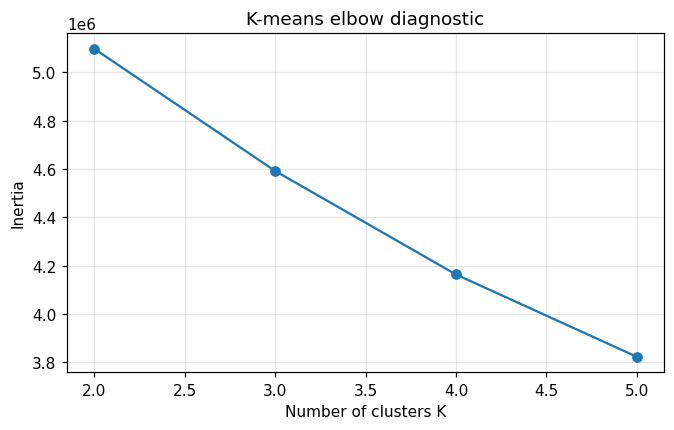

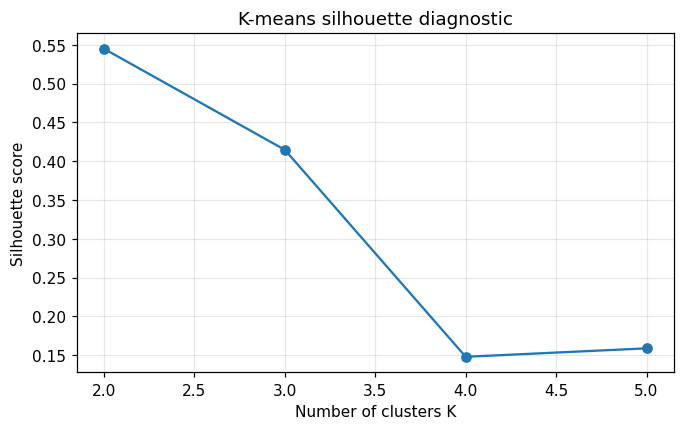

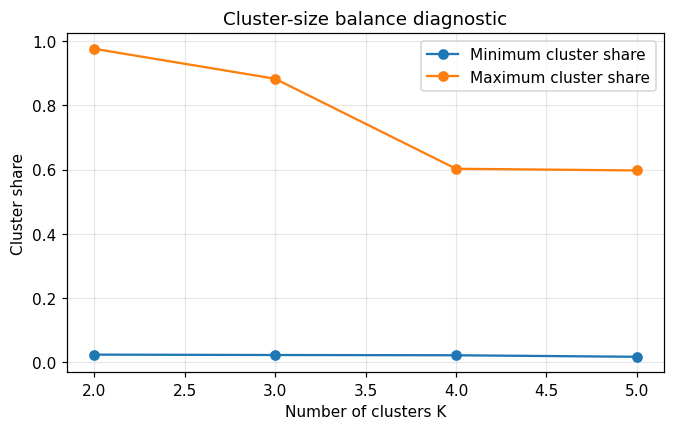

In [31]:
# Elbow plot:
plt.figure(figsize=(7, 4))
plt.plot(k_diagnostics_df["K"], k_diagnostics_df["inertia"], marker="o")
plt.xlabel("Number of clusters K")
plt.ylabel("Inertia")
plt.title("K-means elbow diagnostic")
plt.grid(True, alpha=0.3)
plt.show()

# Silhouette plot:
plt.figure(figsize=(7, 4))
plt.plot(k_diagnostics_df["K"], k_diagnostics_df["silhouette"], marker="o")
plt.xlabel("Number of clusters K")
plt.ylabel("Silhouette score")
plt.title("K-means silhouette diagnostic")
plt.grid(True, alpha=0.3)
plt.show()

# Cluster balance plot:
plt.figure(figsize=(7, 4))
plt.plot(k_diagnostics_df["K"], k_diagnostics_df["min_cluster_share"], marker="o", label="Minimum cluster share")
plt.plot(k_diagnostics_df["K"], k_diagnostics_df["max_cluster_share"], marker="o", label="Maximum cluster share")
plt.xlabel("Number of clusters K")
plt.ylabel("Cluster share")
plt.title("Cluster-size balance diagnostic")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### d. Detailed cluster-size table for each candidate K

In [32]:
cluster_size_tables = {}

for K in candidate_K:
    
    # Use the stored fitted KMeans model.
    kmeans = kmeans_models[K]
    
    # Assign each training observation to a cluster.
    labels = kmeans.predict(X_cluster_train)
    
    # Count observations in each cluster.
    counts = pd.Series(labels, name="cluster").value_counts().sort_index()
    
    # Convert counts into shares.
    shares = counts / counts.sum()
    
    # Build a readable table.
    size_table = pd.DataFrame({
        "count": counts,
        "share": shares
    })
    
    cluster_size_tables[K] = size_table
    
    print(f"\nCluster size table for K = {K}")
    display(size_table)


Cluster size table for K = 2


,count,share
cluster,,
0,504535,0.975637
1,12599,0.024363



Cluster size table for K = 3


,count,share
cluster,,
0,456342,0.882444
1,48789,0.094345
2,12003,0.023211



Cluster size table for K = 4


,count,share
cluster,,
0,149648,0.289380
1,44339,0.085740
2,311566,0.602486
3,11581,0.022395



Cluster size table for K = 5


,count,share
cluster,,
0,11387,0.022019
1,308873,0.597278
2,148501,0.287162
3,9122,0.017640
4,39251,0.075901


### e. Inspect centroid profiles for economic interpretation

In [33]:
def get_centroid_profile(kmeans_model, feature_names):
    """
    Convert KMeans cluster centroids into a readable DataFrame.
    
    Parameters
    ----------
    kmeans_model:
        A fitted sklearn KMeans object.
        
    feature_names:
        Names of the clustering variables used to fit KMeans.
        
    Returns
    -------
    centroid_df:
        DataFrame where each row is a cluster centroid and each column
        is a clustering feature.
        
    Important interpretation:
    Because the clustering variables were standardized in preprocessing,
    a positive centroid value means the cluster is above the training-sample
    average for that feature, while a negative value means below average.
    """
    
    centroid_df = pd.DataFrame(
        kmeans_model.cluster_centers_,
        columns=feature_names
    )
    
    centroid_df.index.name = "cluster"
    
    return centroid_df


# Print centroid profiles for each candidate K.
# These tables are useful for deciding whether clusters are economically meaningful.
centroid_profiles = {}

for K in candidate_K:
    
    centroid_profiles[K] = get_centroid_profile(
        kmeans_model=kmeans_models[K],
        feature_names=log_cluster_features
    )
    
    print(f"\nCentroid profile for K = {K}")
    display(centroid_profiles[K].round(3))


Centroid profile for K = 2


,log_age,gp_at,ocf_at,sale_gr1,inv_gr1,dsale_dinv,netdebt_me,kz_index,z_score,niq_su,ni_inc8q
cluster,,,,,,,,,,,
0,0.009,0.016,0.011,-0.013,-0.122,0.114,-0.010,0.003,0.003,0.002,0.004
1,-0.364,-0.647,-0.426,0.511,4.879,-4.543,0.384,-0.132,-0.105,-0.087,-0.172



Centroid profile for K = 3


,log_age,gp_at,ocf_at,sale_gr1,inv_gr1,dsale_dinv,netdebt_me,kz_index,z_score,niq_su,ni_inc8q
cluster,,,,,,,,,,,
0,0.097,0.140,0.214,-0.115,-0.127,0.095,0.033,0.132,-0.102,-0.005,0.04
1,-0.823,-1.146,-1.909,0.964,-0.030,0.266,-0.404,-1.205,0.981,0.071,-0.33
2,-0.350,-0.641,-0.378,0.448,4.967,-4.700,0.405,-0.101,-0.128,-0.088,-0.17



Centroid profile for K = 4


,log_age,gp_at,ocf_at,sale_gr1,inv_gr1,dsale_dinv,netdebt_me,kz_index,z_score,niq_su,ni_inc8q
cluster,,,,,,,,,,,
0,0.236,0.344,0.368,0.086,-0.078,0.163,-0.149,0.068,0.080,0.006,1.361
1,-0.844,-1.210,-2.027,1.017,-0.030,0.271,-0.413,-1.244,1.033,0.076,-0.363
2,0.020,0.031,0.126,-0.203,-0.146,0.061,0.115,0.148,-0.181,-0.011,-0.596
3,-0.350,-0.646,-0.386,0.454,5.056,-4.784,0.401,-0.107,-0.128,-0.082,-0.177



Centroid profile for K = 5


,log_age,gp_at,ocf_at,sale_gr1,inv_gr1,dsale_dinv,netdebt_me,kz_index,z_score,niq_su,ni_inc8q
cluster,,,,,,,,,,,
0,-0.344,-0.645,-0.374,0.452,5.074,-4.833,0.406,-0.059,-0.132,-0.083,-0.175
1,0.028,0.041,0.144,-0.207,-0.147,0.060,0.117,0.148,-0.174,-0.011,-0.596
2,0.237,0.334,0.364,0.082,-0.078,0.163,-0.148,0.094,0.081,0.005,1.366
3,-0.528,-0.476,-0.401,0.432,-0.046,0.140,-0.289,-6.509,1.057,0.006,-0.116
4,-0.890,-1.289,-2.308,1.084,-0.010,0.283,-0.410,0.009,0.850,0.085,-0.398


### f. Visualize centroid profiles

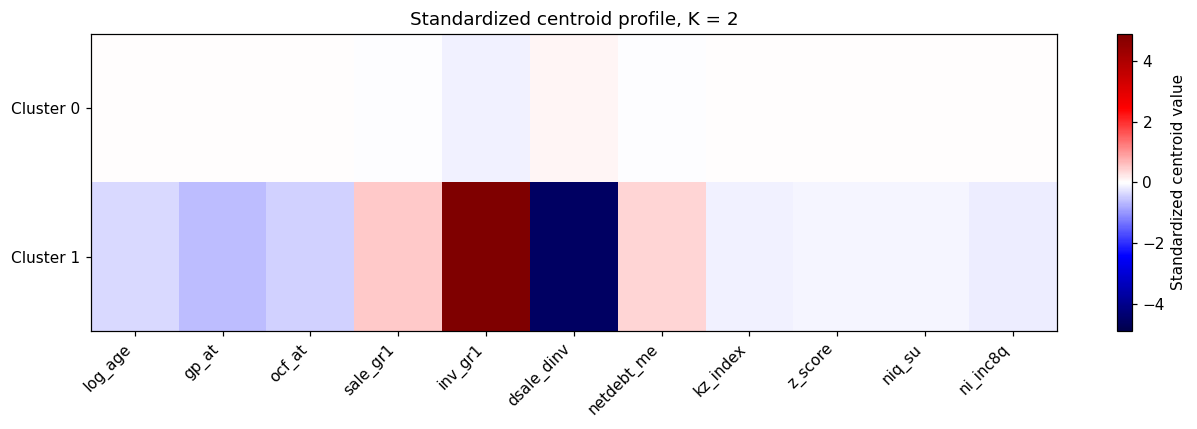

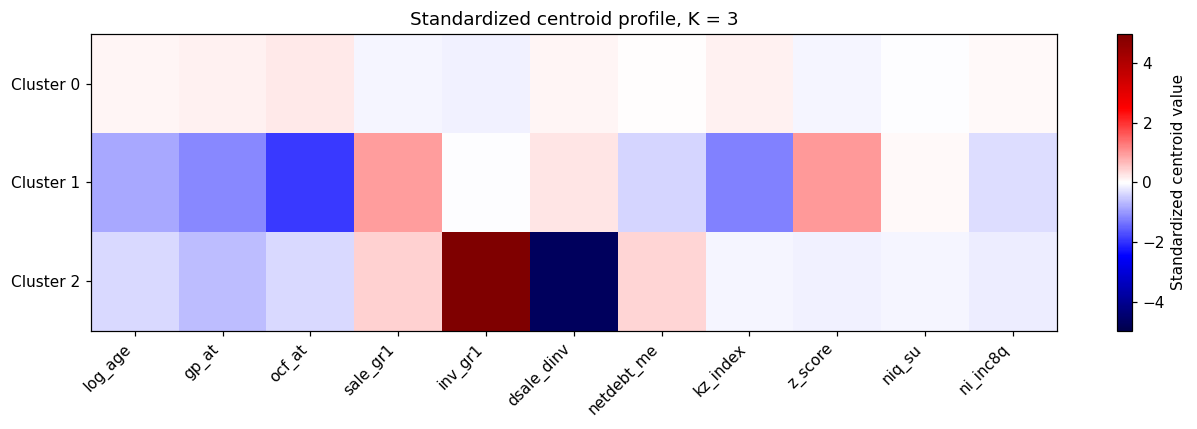

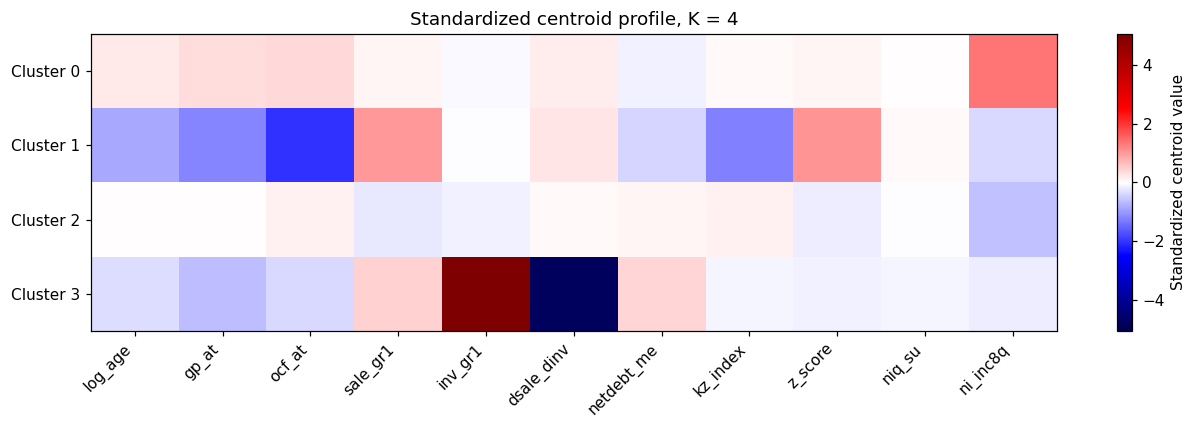

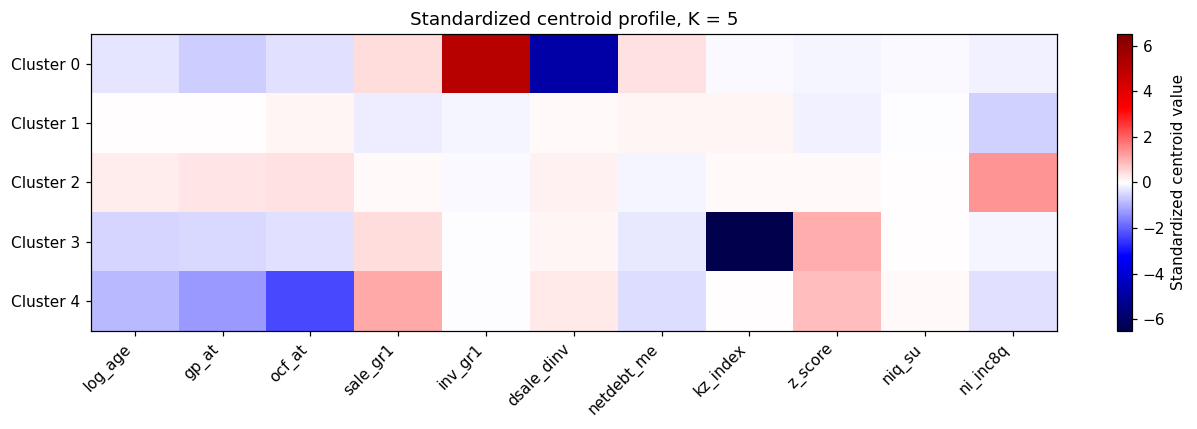

In [34]:


def plot_centroid_heatmap(centroid_df, title):
    """
    Plot a heatmap of standardized cluster centroids.

    Since features are standardized:
    - positive values mean the cluster is above the training-sample average
      for that characteristic
    - negative values mean the cluster is below the training-sample average
      for that characteristic
    - values close to zero mean the cluster is close to the average firm

    We use a diverging color map because centroid values can be positive
    or negative. This makes above-average and below-average characteristics
    visually easier to separate.
    """

    plt.figure(figsize=(12, 4))

    # Use symmetric color limits so that positive and negative values
    # are treated equally in the heatmap.
    # Example:
    # if max absolute centroid value is 5, then the color scale is [-5, +5].
    vmax = np.abs(centroid_df.values).max()
    vmin = -vmax

    plt.imshow(
        centroid_df.values,
        aspect="auto",
        cmap="seismic",
        vmin=vmin,
        vmax=vmax
    )

    # Add color bar to show the meaning of colors.
    plt.colorbar(label="Standardized centroid value")

    # Set feature names on the x-axis.
    plt.xticks(
        ticks=np.arange(len(centroid_df.columns)),
        labels=centroid_df.columns,
        rotation=45,
        ha="right"
    )

    # Set cluster labels on the y-axis.
    plt.yticks(
        ticks=np.arange(len(centroid_df.index)),
        labels=[f"Cluster {i}" for i in centroid_df.index]
    )

    plt.title(title)
    plt.tight_layout()
    plt.show()


# Plot centroid heatmaps for each candidate K.
for K in candidate_K:
    plot_centroid_heatmap(
        centroid_df=centroid_profiles[K],
        title=f"Standardized centroid profile, K = {K}"
    )

### g. Fit final diagnostic K-means model on the original training period

Selected number of clusters, K_star = 4
Cluster size table for selected K:


,count,share
cluster,,
0,149648,0.289380
1,44339,0.085740
2,311566,0.602486
3,11581,0.022395


Centroid profile for selected K:


,log_age,gp_at,ocf_at,sale_gr1,inv_gr1,dsale_dinv,netdebt_me,kz_index,z_score,niq_su,ni_inc8q
cluster,,,,,,,,,,,
0,0.236,0.344,0.368,0.086,-0.078,0.163,-0.149,0.068,0.080,0.006,1.361
1,-0.844,-1.210,-2.027,1.017,-0.030,0.271,-0.413,-1.244,1.033,0.076,-0.363
2,0.020,0.031,0.126,-0.203,-0.146,0.061,0.115,0.148,-0.181,-0.011,-0.596
3,-0.350,-0.646,-0.386,0.454,5.056,-4.784,0.401,-0.107,-0.128,-0.082,-0.177


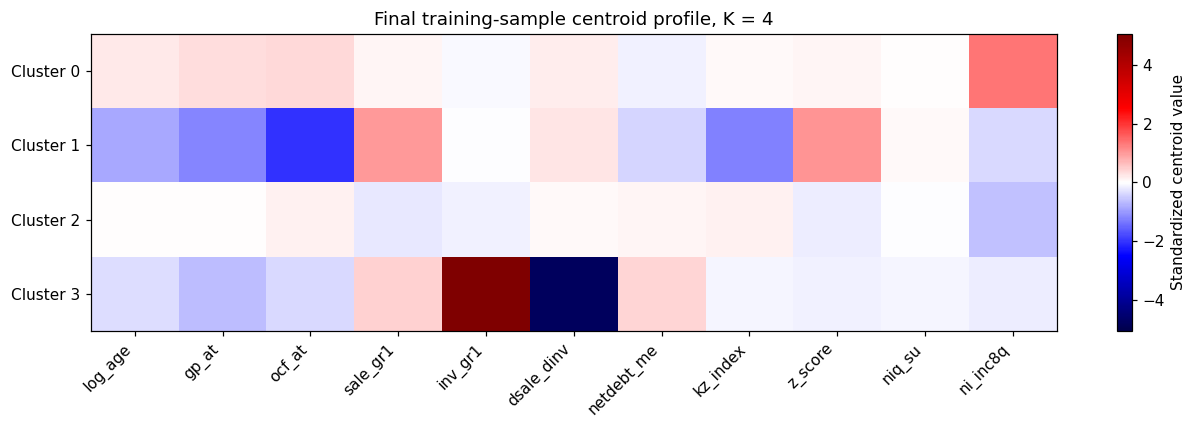

In [35]:
# ------------------------------------------------------------
# Manually select K after reviewing diagnostics
# ------------------------------------------------------------
K_star = 4
print("Selected number of clusters, K_star =", K_star)


# This model is mainly for reporting and interpretation in Section 2.1.
# Later, during validation and test expanding-window loops, we will refit K-means centroids at each refit date using the current estimation window.
kmeans_train_final = KMeans(
    n_clusters=K_star,
    random_state=random_state,
    n_init=20
)

train_cluster_labels = kmeans_train_final.fit_predict(X_cluster_train)

# Attach cluster labels to the training dataframe for interpretation.
train_cluster_diagnostic = train_for_k[["id", "eom", target]].copy()
train_cluster_diagnostic["cluster"] = train_cluster_labels

# Cluster size table for selected K.
selected_cluster_size = (
    train_cluster_diagnostic["cluster"]
    .value_counts()
    .sort_index()
    .to_frame("count")
)

selected_cluster_size["share"] = selected_cluster_size["count"] / selected_cluster_size["count"].sum()

print("Cluster size table for selected K:")
display(selected_cluster_size)


# Centroid profile for selected K.
selected_centroid_profile = get_centroid_profile(
    kmeans_model=kmeans_train_final,
    feature_names=log_cluster_features
)

print("Centroid profile for selected K:")
display(selected_centroid_profile.round(3))


# Visualize centroid profile for selected K.
plot_centroid_heatmap(
    centroid_df=selected_centroid_profile,
    title=f"Final training-sample centroid profile, K = {K_star}"
)

In [36]:
# ------------------------------------------------------------
# Characteristic importance in cluster formation
# ------------------------------------------------------------

# The intuition follows the paper's appendix:
# if cluster centroids are very spread out along one feature,
# that feature is important for separating the clusters.

centroid_dispersion = selected_centroid_profile.var(axis=0).sort_values(ascending=False)

centroid_importance = centroid_dispersion.to_frame("centroid_variance")
centroid_importance["rank"] = range(1, len(centroid_importance) + 1)

display(centroid_importance)

,centroid_variance,rank
inv_gr1,6.608909,1
dsale_dinv,6.130311,2
ocf_at,1.162715,3
ni_inc8q,0.786279,4
gp_at,0.484052,5
kz_index,0.421176,6
z_score,0.320350,7
sale_gr1,0.277125,8
log_age,0.223737,9
netdebt_me,0.121930,10


**->> K = 4**

**Cluster 0**: stronger / mature / profitable firms
- log_age, gp_at, ocf_at: positive
- ni_inc8q: strongly positive
- netdebt_me: negative

**Cluster 1:** young growth / weak profitability but better z-score
- log_age, ocf_at: very negative
- gp_at, kz_index: negative
- sale_gr1, z_score: positive

**Cluster 2:** broad normal / average firms
- Most centroid values are close to 0

**Cluster 3:** abnormal investment-growth group
- inv_gr1: extremely high
- dsale_dinv: extremely negative
- netdebt_me: positive


### (Don't run, just for inspection) Alternative clustering feature set for robustness inspection

- remove `inv_gr1` and `dsale_dinv` as they dominate the clustering



In [37]:
# # ------------------------------------------------------------
# # Alternative clustering feature set for robustness inspection
# # ------------------------------------------------------------

# # Baseline clustering features:
# # cluster_features = [
# #     'age',
# #     'gp_at', 'ocf_at', 'sale_gr1', 'inv_gr1', 'dsale_dinv',
# #     'netdebt_me', 'kz_index', 'z_score',
# #     'niq_su', 'ni_inc8q'
# # ]

# # Alternative clustering features:
# # We remove inv_gr1 and dsale_dinv because the centroid-dispersion
# # diagnostic shows that they strongly dominate the baseline clustering.
# cluster_features_alt = [
#     'age',
#     'gp_at', 'ocf_at', 'sale_gr1',
#     'netdebt_me', 'kz_index', 'z_score',
#     'niq_su', 'ni_inc8q'
# ]

# # Convert raw feature names into processed feature names.
# # Since age is log-transformed during preprocessing, downstream code
# # should use log_age instead of raw age.
# log_cluster_features_alt = [
#     'log_age' if col == 'age' else col
#     for col in cluster_features_alt
# ]

# print("Baseline clustering features:")
# print(log_cluster_features)

# print("\nAlternative clustering features:")
# print(log_cluster_features_alt)

# # ------------------------------------------------------------
# # Reusable K-means diagnostic function
# # ------------------------------------------------------------

# def run_kmeans_diagnostics(
#     X_cluster,
#     feature_names,
#     candidate_K=[2, 3, 4, 5],
#     silhouette_sample_size=10000,
#     random_state=42,
#     n_init=20
# ):
#     """
#     Run K-means diagnostics for several candidate K values.

#     Parameters
#     ----------
#     X_cluster : pandas DataFrame
#         The preprocessed clustering feature matrix.
#         Columns should already be standardized and should contain no missing values.

#     feature_names : list
#         Names of clustering features used in K-means.
#         This is used to label centroid tables.

#     candidate_K : list
#         Candidate numbers of clusters to test.

#     silhouette_sample_size : int
#         Maximum number of observations used to compute silhouette score.
#         K-means is still fitted on the full training sample.
#         The sample is only used to make silhouette calculation faster.

#     random_state : int
#         Random seed for reproducibility.

#     n_init : int
#         Number of random centroid initializations used by KMeans.
#         A larger value makes the result less sensitive to unlucky starting points.

#     Returns
#     -------
#     diagnostics_df : pandas DataFrame
#         Summary table containing inertia, silhouette score,
#         minimum cluster share, and maximum cluster share for each K.

#     kmeans_models : dict
#         Dictionary storing the fitted KMeans model for each K.

#     centroid_profiles : dict
#         Dictionary storing centroid profile DataFrame for each K.

#     cluster_size_tables : dict
#         Dictionary storing cluster count and share table for each K.
#     """

#     # Defensive check: K-means cannot handle missing values.
#     assert X_cluster.isna().sum().sum() == 0, "X_cluster still contains missing values."

#     k_diagnostics = []
#     kmeans_models = {}
#     centroid_profiles = {}
#     cluster_size_tables = {}

#     for K in candidate_K:

#         # KMeans groups observations by minimizing within-cluster squared distance.
#         kmeans = KMeans(
#             n_clusters=K,
#             random_state=random_state,
#             n_init=n_init
#         )

#         # Fit K-means on the full training sample.
#         cluster_labels = kmeans.fit_predict(X_cluster)

#         # Inertia is the within-cluster sum of squared distances.
#         # It always decreases as K increases, so we look for an "elbow",
#         # not simply the lowest value.
#         inertia = kmeans.inertia_

#         # Compute cluster sizes.
#         cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
#         cluster_shares = cluster_counts / cluster_counts.sum()

#         # Silhouette score measures cluster separation.
#         # To save time, compute it on a random subsample if the panel is large.
#         if len(X_cluster) > silhouette_sample_size:
#             X_sil = X_cluster.sample(
#                 n=silhouette_sample_size,
#                 random_state=random_state
#             )

#             # Use the fitted K-means model to assign labels to the sampled rows.
#             labels_sil = kmeans.predict(X_sil)

#             silhouette = silhouette_score(X_sil, labels_sil)
#         else:
#             silhouette = silhouette_score(X_cluster, cluster_labels)

#         # Store summary diagnostics.
#         k_diagnostics.append({
#             "K": K,
#             "inertia": inertia,
#             "silhouette": silhouette,
#             "min_cluster_share": cluster_shares.min(),
#             "max_cluster_share": cluster_shares.max()
#         })

#         # Store fitted model.
#         kmeans_models[K] = kmeans

#         # Store cluster-size table.
#         cluster_size_tables[K] = pd.DataFrame({
#             "count": cluster_counts,
#             "share": cluster_shares
#         })

#         # Store centroid profile.
#         # Because features are standardized, positive centroid values mean
#         # above-average cluster characteristics; negative values mean below average.
#         centroid_profiles[K] = pd.DataFrame(
#             kmeans.cluster_centers_,
#             columns=feature_names
#         )
#         centroid_profiles[K].index.name = "cluster"

#     diagnostics_df = pd.DataFrame(k_diagnostics)

#     return diagnostics_df, kmeans_models, centroid_profiles, cluster_size_tables


# # ------------------------------------------------------------
# # Plot diagnostic curves
# # ------------------------------------------------------------

# def plot_kmeans_diagnostics(diagnostics_df, title_prefix="K-means"):
#     """
#     Plot inertia, silhouette score, and cluster-size balance
#     for K-means diagnostics.
#     """

#     # Elbow / inertia plot
#     plt.figure(figsize=(7, 4))
#     plt.plot(diagnostics_df["K"], diagnostics_df["inertia"], marker="o")
#     plt.xlabel("Number of clusters K")
#     plt.ylabel("Inertia")
#     plt.title(f"{title_prefix}: elbow diagnostic")
#     plt.grid(True, alpha=0.3)
#     plt.show()

#     # Silhouette plot
#     plt.figure(figsize=(7, 4))
#     plt.plot(diagnostics_df["K"], diagnostics_df["silhouette"], marker="o")
#     plt.xlabel("Number of clusters K")
#     plt.ylabel("Silhouette score")
#     plt.title(f"{title_prefix}: silhouette diagnostic")
#     plt.grid(True, alpha=0.3)
#     plt.show()

#     # Cluster-size balance plot
#     plt.figure(figsize=(7, 4))
#     plt.plot(
#         diagnostics_df["K"],
#         diagnostics_df["min_cluster_share"],
#         marker="o",
#         label="Minimum cluster share"
#     )
#     plt.plot(
#         diagnostics_df["K"],
#         diagnostics_df["max_cluster_share"],
#         marker="o",
#         label="Maximum cluster share"
#     )
#     plt.xlabel("Number of clusters K")
#     plt.ylabel("Cluster share")
#     plt.title(f"{title_prefix}: cluster-size balance")
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     plt.show()

# # ------------------------------------------------------------
# # Baseline K-means diagnostic
# # ------------------------------------------------------------

# X_cluster_train_base = train_for_k[log_cluster_features].copy()

# base_diag_df, base_kmeans_models, base_centroids, base_size_tables = run_kmeans_diagnostics(
#     X_cluster=X_cluster_train_base,
#     feature_names=log_cluster_features,
#     candidate_K=[2, 3, 4, 5],
#     silhouette_sample_size=10000,
#     random_state=42,
#     n_init=20
# )

# display(base_diag_df)

# plot_kmeans_diagnostics(
#     diagnostics_df=base_diag_df,
#     title_prefix="Baseline clustering features"
# )

# for K in [2, 3, 4, 5]:
#     print(f"\nBaseline cluster size table for K = {K}")
#     display(base_size_tables[K])

#     print(f"\nBaseline centroid profile for K = {K}")
#     display(base_centroids[K].round(3))


# # ------------------------------------------------------------
# # Alternative K-means diagnostic
# # ------------------------------------------------------------

# X_cluster_train_alt = train_for_k[log_cluster_features_alt].copy()

# alt_diag_df, alt_kmeans_models, alt_centroids, alt_size_tables = run_kmeans_diagnostics(
#     X_cluster=X_cluster_train_alt,
#     feature_names=log_cluster_features_alt,
#     candidate_K=[2, 3, 4, 5],
#     silhouette_sample_size=10000,
#     random_state=42,
#     n_init=20
# )

# display(alt_diag_df)

# plot_kmeans_diagnostics(
#     diagnostics_df=alt_diag_df,
#     title_prefix="Alternative clustering features"
# )

# for K in [2, 3, 4, 5]:
#     print(f"\nAlternative cluster size table for K = {K}")
#     display(alt_size_tables[K])

#     print(f"\nAlternative centroid profile for K = {K}")
#     display(alt_centroids[K].round(3))

# # ------------------------------------------------------------
# # Compare baseline and alternative diagnostics
# # ------------------------------------------------------------

# base_compare = base_diag_df.copy()
# base_compare["specification"] = "Baseline"

# alt_compare = alt_diag_df.copy()
# alt_compare["specification"] = "Alternative"

# kmeans_compare_df = pd.concat(
#     [base_compare, alt_compare],
#     axis=0,
#     ignore_index=True
# )

# # Reorder columns for readability.
# kmeans_compare_df = kmeans_compare_df[
#     ["specification", "K", "inertia", "silhouette", "min_cluster_share", "max_cluster_share"]
# ]

# display(kmeans_compare_df)


# # ------------------------------------------------------------
# # Centroid-dispersion ranking
# # ------------------------------------------------------------

# def centroid_dispersion_ranking(centroid_df):
#     """
#     Rank clustering features by how much their centroids differ across clusters.

#     If a feature has high centroid variance, that feature strongly separates clusters.
#     """

#     centroid_variance = centroid_df.var(axis=0).sort_values(ascending=False)

#     importance_df = centroid_variance.to_frame("centroid_variance")
#     importance_df["rank"] = range(1, len(importance_df) + 1)

#     return importance_df


# # Choose K = 4 for inspection first.
# K_inspect = 4

# print("Baseline centroid-dispersion ranking:")
# base_importance = centroid_dispersion_ranking(base_centroids[K_inspect])
# display(base_importance)

# print("\nAlternative centroid-dispersion ranking:")
# alt_importance = centroid_dispersion_ranking(alt_centroids[K_inspect])
# display(alt_importance)

## 2.2. Validation Portfolio Rule —— Function Defining


**Objective**

Define a fixed rule that converts **stock-level predicted returns** into **monthly long–short portfolio returns** during validation tuning.

**Rank-based long–short rule**

For each validation month:

1. Rank stocks by predicted return.
2. Center the ranks to make the portfolio approximately **dollar-neutral**.
3. Normalize weights so total absolute exposure equals **1**.
4. Compute portfolio return using realized `ret_exc_lead1m`.

**This gives:**

- **higher predicted return** → positive weight / long position
- **lower predicted return** → negative weight / short position
- **rank-based weights** → less sensitive to extreme prediction values

**Role in tuning**

We use the same portfolio rule for:

- pooled Elastic Net tuning
- clustered Elastic Net tuning

The resulting validation-period **Sharpe ratio** is the main criterion for choosing Elastic Net hyperparameters.

Note:

This section only defines the validation portfolio rule. Final test-period portfolio evaluation is reported later.

### Rule1: Rank - based function

#### a. make_rank_long_short_weights()

In [ ]:
def make_rank_long_short_weights(
    pred_df,
    date_col="eom",
    pred_col="y_pred",
    id_col="id",
    min_stocks_per_month=20,
    max_abs_weight=None
):
    """
    Construct monthly rank-based zero-cost long-short portfolio weights.

    Some Parameters
    ----------
    min_stocks_per_month : int
        Minimum number of valid stock predictions required in a month.
        If a month has too few stocks, portfolio weights are not constructed
        for that month.

    max_abs_weight : float or None
        Optional maximum absolute weight for each stock.

        Example:
        max_abs_weight = 0.01 means no single stock can have weight
        larger than 1% or smaller than -1%.

        If None, no individual stock weight cap is applied.

    Returns
    -------
    weight_df : pandas DataFrame
        Original prediction DataFrame with an additional column:
        - weight

    Notes
    -----
    The portfolio is rank-based:

    - Stocks with higher predicted returns receive higher ranks.
    - Ranks are centered by subtracting the average rank.
    - Centered ranks are normalized so that the sum of absolute weights equals 1.

    Therefore:
    - sum of weights is approximately 0
    - sum of absolute weights is approximately 1
    - positive weights are long positions
    - negative weights are short positions
    """

    df = pred_df.copy()

    df[date_col] = pd.to_datetime(df[date_col])

    # Keep only rows with valid predictions.
    # Stocks without predictions cannot receive portfolio weights.
    df = df.dropna(subset=[pred_col]).copy()

    # This list stores each month's dataframe after weights are assigned.
    monthly_weight_dfs = []

    # Group the dataframe by month.
    # Each month gets its own cross-sectional long-short portfolio.
    for date, month_df in df.groupby(date_col):
        # date      = one month, e.g. 2016-01-31
        # month_df  = all stocks in that month
        month_df = month_df.copy()

        # If the month has too few stocks, skip it.
        # This avoids constructing unstable portfolios from tiny cross-sections.
        if len(month_df) < min_stocks_per_month:
            continue

        # If all predictions are the same within a month, the model provides
        # no cross-sectional ranking information for that month.
        # In that case, we skip the month instead of creating arbitrary ranks.
        if month_df[pred_col].nunique() <= 1:
            continue

        # Rank stocks by predicted return within the month.
            # method="average":
            # Stocks with the same prediction receive the same average rank.
        ranks = month_df[pred_col].rank(method="average", ascending=True)


        # Center ranks by subtracting the average rank.
            # After this step:
            # - stocks with above-average predicted rank have positive values 
            # - stocks with below-average predicted rank have negative values
            # - the centered ranks sum to zero
        centered_ranks = ranks - ranks.mean()

        # If all predictions are identical, centered ranks may be all zero.
        # In that case, we cannot form meaningful long-short weights.
        gross_exposure = centered_ranks.abs().sum()

        if gross_exposure == 0:
            continue

        # Normalize weights so that sum(abs(weights)) = 1.
            # This creates a dollar-neutral long-short portfolio with one unit of gross exposure.
        weights = centered_ranks / gross_exposure

        # Optional individual stock weight cap.
            # This is not necessary for the baseline rule, but the option is useful
            # if we want to avoid very large single-stock weights in small months.
        if max_abs_weight is not None:

            # Clip weights to the specified maximum absolute weight.
            weights = weights.clip(
                lower=-max_abs_weight,
                upper=max_abs_weight
            )

            # Re-center weights to restore approximate dollar neutrality.
            weights = weights - weights.mean()

            # Re-normalize to restore unit gross exposure if possible.
            gross_after_cap = weights.abs().sum()

            if gross_after_cap > 0:
                weights = weights / gross_after_cap
            else:
                continue

        # Store the weights.
        month_df["weight"] = weights

        monthly_weight_dfs.append(month_df)

    # Combine all monthly portfolios.
    if len(monthly_weight_dfs) == 0:
        raise ValueError("No valid monthly portfolios were constructed.")

    weight_df = pd.concat(monthly_weight_dfs, axis=0).sort_values([date_col, id_col])

    return weight_df

#### b. compute_rank_long_short_returns()

In [ ]:
def compute_rank_long_short_returns(
    pred_df,
    date_col="eom",
    id_col="id",
    pred_col="y_pred",
    ret_col="ret_exc_lead1m",
    min_stocks_per_month=20,
    max_abs_weight=None
):
    """
    Construct rank-based long-short portfolio returns from stock-level predictions.

    Returns
    -------
    pf_returns : pandas Series
        Monthly portfolio excess returns.

    weight_df : pandas DataFrame
        Stock-level prediction dataframe with portfolio weights.

    Notes
    -----
    The realized return used here is `ret_exc_lead1m`.

    Since `ret_exc_lead1m` is already the next-month excess return,
    we do not manually shift or lag the return again.
    """

    # Drop rows where realized return is missing.
    clean_pred_df = pred_df.dropna(subset=[pred_col, ret_col]).copy()

    # First construct stock-level portfolio weights.
    weight_df = make_rank_long_short_weights(
        pred_df=clean_pred_df,
        date_col=date_col,
        pred_col=pred_col,
        id_col=id_col,
        min_stocks_per_month=min_stocks_per_month,
        max_abs_weight=max_abs_weight
    )

    # Portfolio return for each month:
    weight_df["weighted_return"] = weight_df["weight"] * weight_df[ret_col]

    pf_returns = (
        weight_df
        .groupby(date_col)["weighted_return"]
        .sum()
        .sort_index()
    )

    pf_returns.name = "portfolio_return"

    return pf_returns, weight_df

#### c. function check —— Portfolio diagnostic checks

In [41]:
# ------------------------------------------------------------
# Portfolio diagnostic checks
# ------------------------------------------------------------

def check_portfolio_weights(
    weight_df,
    date_col="eom",
    weight_col="weight"
):
    """
    Check whether portfolio weights are constructed correctly.

    For a zero-cost long-short portfolio, we expect:
    - sum of weights close to 0
    - sum of absolute weights close to 1
    - positive weights represent long positions
    - negative weights represent short positions
    """

    weight_check = (
        weight_df
        .groupby(date_col)[weight_col]
        .agg(
            net_exposure="sum",
            gross_exposure=lambda x: x.abs().sum(),
            max_long="max",
            max_short="min",
            n_stocks="count"
        )
    )

    return weight_check

### Rule2: Prediction-scaled long-short weights

In [2]:
# ------------------------------------------------------------
# Prediction-scaled zero-cost long-short weights
# ------------------------------------------------------------

def make_prediction_scaled_weights(
    pred_df,
    date_col="eom",
    pred_col="y_pred",
    id_col="id",
    min_stocks_per_month=20,
    max_abs_weight=None
):
    """
    Construct monthly long-short weights using predicted-return magnitudes.

    For each month:
    1. Center predicted returns by subtracting the monthly average prediction.
    2. Normalize the centered predictions so sum(abs(weights)) = 1.

    This rule uses prediction magnitudes, not ranks.
    It is useful if predicted returns are reasonably well distributed
    and their magnitudes contain useful information.
    """

    df = pred_df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.dropna(subset=[pred_col]).copy()

    monthly_weight_dfs = []

    for date, month_df in df.groupby(date_col):

        month_df = month_df.copy()

        if len(month_df) < min_stocks_per_month:
            continue

        # Center predictions so positive values become long positions
        # and negative values become short positions.
        centered_pred = month_df[pred_col] - month_df[pred_col].mean()

        gross_exposure = centered_pred.abs().sum()

        # If all predictions are the same, no meaningful magnitude signal exists.
        if gross_exposure == 0:
            continue

        weights = centered_pred / gross_exposure

        # Optional individual stock weight cap.
        if max_abs_weight is not None:
            weights = weights.clip(lower=-max_abs_weight, upper=max_abs_weight)

            # Re-center and re-normalize after clipping.
            weights = weights - weights.mean()
            gross_after_cap = weights.abs().sum()

            if gross_after_cap > 0:
                weights = weights / gross_after_cap
            else:
                continue

        month_df["weight"] = weights
        monthly_weight_dfs.append(month_df)

    if len(monthly_weight_dfs) == 0:
        raise ValueError("No valid monthly portfolios were constructed.")

    weight_df = pd.concat(monthly_weight_dfs, axis=0).sort_values([date_col, id_col])

    return weight_df

### Rule3: Top-bottom quantile long-short weights

In [3]:
# ------------------------------------------------------------
# Top-bottom quantile zero-cost long-short weights
# ------------------------------------------------------------

def make_top_bottom_quantile_weights(
    pred_df,
    date_col="eom",
    pred_col="y_pred",
    id_col="id",
    min_stocks_per_month=20,
    top_bottom_frac=0.2
):
    """
    Construct monthly top-bottom quantile long-short weights.

    For each month:
    - Long the top predicted-return stocks.
    - Short the bottom predicted-return stocks.
    - Equal weight within the long side and short side.

    Example:
    top_bottom_frac = 0.2 means:
    - long top 20%
    - short bottom 20%

    This is simple and common in empirical asset-pricing projects.
    """

    df = pred_df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.dropna(subset=[pred_col]).copy()

    monthly_weight_dfs = []

    for date, month_df in df.groupby(date_col):

        month_df = month_df.copy()

        if len(month_df) < min_stocks_per_month:
            continue

        n = len(month_df)
        n_side = int(np.floor(n * top_bottom_frac))

        # Need at least one stock on each side.
        if n_side < 1:
            continue

        # Rank predictions from low to high.
        month_df = month_df.sort_values(pred_col).copy()

        # Initialize all weights as zero.
        month_df["weight"] = 0.0

        # Bottom group: short side.
        short_idx = month_df.index[:n_side]

        # Top group: long side.
        long_idx = month_df.index[-n_side:]

        # Equal-weight long and short sides.
        # Long side total weight = +0.5
        # Short side total weight = -0.5
        # Therefore gross exposure = 1 and net exposure = 0.
        month_df.loc[long_idx, "weight"] = 0.5 / n_side
        month_df.loc[short_idx, "weight"] = -0.5 / n_side

        monthly_weight_dfs.append(month_df)

    if len(monthly_weight_dfs) == 0:
        raise ValueError("No valid monthly portfolios were constructed.")

    weight_df = pd.concat(monthly_weight_dfs, axis=0).sort_values([date_col, id_col])

    return weight_df

### Generic function: choose portfolio rule by name

In [4]:
# ------------------------------------------------------------
# Generic portfolio return function
# ------------------------------------------------------------

def compute_portfolio_returns_by_rule(
    pred_df,
    portfolio_rule,
    date_col="eom",
    id_col="id",
    pred_col="y_pred",
    ret_col="ret_exc_lead1m",
    min_stocks_per_month=20,
    max_abs_weight=None,
    top_bottom_frac=0.2
):
    """
    Compute monthly portfolio returns using a selected portfolio rule.

    portfolio_rule options:
    - "rank": rank-based long-short weights
    - "scaled": prediction-scaled long-short weights
    - "top_bottom": top-bottom quantile long-short weights
    """

    clean_df = pred_df.dropna(subset=[pred_col, ret_col]).copy()

    if portfolio_rule == "rank":
        weight_df = make_rank_long_short_weights(
            pred_df=clean_df,
            date_col=date_col,
            pred_col=pred_col,
            id_col=id_col,
            min_stocks_per_month=min_stocks_per_month,
            max_abs_weight=max_abs_weight
        )

    elif portfolio_rule == "scaled":
        weight_df = make_prediction_scaled_weights(
            pred_df=clean_df,
            date_col=date_col,
            pred_col=pred_col,
            id_col=id_col,
            min_stocks_per_month=min_stocks_per_month,
            max_abs_weight=max_abs_weight
        )

    elif portfolio_rule == "top_bottom":
        weight_df = make_top_bottom_quantile_weights(
            pred_df=clean_df,
            date_col=date_col,
            pred_col=pred_col,
            id_col=id_col,
            min_stocks_per_month=min_stocks_per_month,
            top_bottom_frac=top_bottom_frac
        )

    else:
        raise ValueError("portfolio_rule must be one of: 'rank', 'scaled', 'top_bottom'.")

    # Portfolio return = sum of stock weight × realized next-month excess return.
    weight_df["weighted_return"] = weight_df["weight"] * weight_df[ret_col]

    pf_returns = (
        weight_df
        .groupby(date_col)["weighted_return"]
        .sum()
        .sort_index()
    )

    pf_returns.name = "portfolio_return"

    return pf_returns, weight_df

## 2.3. Pooled Elastic Net Tuning

**Objective**

Tune the regularized non-clustered benchmark model.

**Model idea**
- `a)pooled Elastic Net` uses the selected prediction variables only. 
- It serves as the regularized benchmark against which we later compare `b)the clustered Elastic Net`.

**Tuning task**

Using the validation period in an expanding-window forecasting exercise, we tune:
- `alpha_pooled`
- `l1_ratio_pooled`

**What this section should do**
- construct the `a)pooled Elastic Net` design matrix,
- define the tuning grid for `alpha` and `l1_ratio_pooled`,
- for each candidate pair, run the full validation-period expanding-window forecasting loop,
- construct validation-period portfolios from the resulting predictions,
- select the pooled Elastic Net hyperparameters using validation portfolio Sharpe ratio.


### a. Function Defining

#### i. fit_predict_pooled_elasticnet()

In [76]:
def fit_predict_pooled_elasticnet(
    est_df,
    pred_df,
    alpha,
    l1_ratio,
    feature_cols,
    target_col,
    id_col="id",
    date_col="eom",
    random_state=42
):
    """
    Fit pooled Elastic Net on one estimation window and predict one future block.

    Some Parameters
    ----------
    alpha : float
        Overall regularization strength in sklearn ElasticNet.
        Larger alpha means stronger coefficient shrinkage.

    l1_ratio : float
        Mixing parameter between L1 and L2 penalties.
        - l1_ratio = 1 means Lasso
        - l1_ratio = 0 means Ridge-like behavior
        - 0 < l1_ratio < 1 means Elastic Net

    Returns
    -------
    pred_out : pandas DataFrame
        DataFrame containing id, eom, realized return, model prediction,
        and historical-average benchmark prediction.
    """

    # Defensive checks: make sure required columns exist.
    required_cols = [id_col, date_col, target_col] + feature_cols
    missing_est_cols = [col for col in required_cols if col not in est_df.columns]
    missing_pred_cols = [col for col in required_cols if col not in pred_df.columns]

    assert len(missing_est_cols) == 0, f"Missing columns in est_df: {missing_est_cols}"
    assert len(missing_pred_cols) == 0, f"Missing columns in pred_df: {missing_pred_cols}"

    # X_train and y_train are used to fit the model.
    X_train = est_df[feature_cols].copy()
    y_train = est_df[target_col].copy()

    # X_pred is the next validation block.
    X_pred = pred_df[feature_cols].copy()

    # ElasticNet is a regularized linear regression model.
        # max_iter is increased to reduce convergence warnings. and because financial data can be noisy and correlated.
        # random_state matters because coordinate descent may involve random behavior when selection="random"; here we keep default selection but set seed anyway.
    model = ElasticNet(
        alpha=alpha,
        l1_ratio=l1_ratio,
        fit_intercept=True,
        max_iter=10000,
        random_state=random_state
    )

    # Fit model on the current estimation window only.
    model.fit(X_train, y_train)

    # Predict the next validation block.
    y_pred = model.predict(X_pred)

    # Historical-average benchmark prediction.
        # This is the mean realized return in the current estimation window.
        # It is used later as the null model for OOS R².
    ha_pred = y_train.mean()

    # Store predictions in a clean dataframe.
    pred_out = pred_df[[id_col, date_col, target_col]].copy()
    pred_out["y_pred"] = y_pred
    pred_out["y_pred_ha"] = ha_pred
    pred_out["alpha"] = alpha
    pred_out["l1_ratio"] = l1_ratio

    return pred_out

#### ii. evaluate_prediction_results() —— OOS R^2, IC, Portfolio Return

In [ ]:
def evaluate_prediction_results(
    pred_df,
    target_col,
    pred_col="y_pred",
    ha_pred_col="y_pred_ha",
    date_col="eom",
    id_col="id",
    min_stocks_per_month=20
):
    """
    Evaluate stock-level predictions and portfolio performance.

    Metrics
    -------
    1. OOS R²:
       Compares model MSE against the historical-average benchmark MSE.

    2. Monthly IC:
       Spearman rank correlation between predicted and realized returns
       within each month.

    3. Portfolio performance:
       Uses the rank-based long-short portfolio rule from Section 2.2.
    """

    df = pred_df.dropna(subset=[target_col, pred_col, ha_pred_col]).copy()

    # --------------------------------------------------------
    # 1. OOS R² against historical-average benchmark
    # --------------------------------------------------------

    mse_model = mean_squared_error(df[target_col], df[pred_col])
    mse_ha = mean_squared_error(df[target_col], df[ha_pred_col])

    oos_r2 = 1 - mse_model / mse_ha

    # --------------------------------------------------------
    # 2. Monthly IC
    # --------------------------------------------------------

    def monthly_spearman_ic(month_df):
        """
        Calculate Spearman rank correlation for one month.

        Spearman IC is used because our portfolio rule is rank-based.
        """
        if len(month_df) < min_stocks_per_month:
            return np.nan

        return month_df[pred_col].corr(
            month_df[target_col],
            method="spearman"
        )

    monthly_ic = (
        df
        .groupby(date_col)
        .apply(monthly_spearman_ic)
        .dropna()
    )

    # On average, are predicted returns positively correlated with realized returns?
    # higher predicted-return stocks tend to have higher realized returns
    mean_ic = monthly_ic.mean()
    
    # How volatile or unstable is the model’s monthly ranking performance?
        # ddof=1 : we are calculating the sample standard deviation, not population standard deviation.
    std_ic = monthly_ic.std(ddof=1)

    # t-statistic for testing:
    # IC t-stat tests whether the average IC is meaningfully different from zero.
    # Is the average IC large compared with the volatility of IC?
    if std_ic > 0:
        ic_tstat = mean_ic / (std_ic / np.sqrt(len(monthly_ic)))
    else:
        ic_tstat = np.nan

    # --------------------------------------------------------
    # 3. Rank-based long-short portfolio returns
    # --------------------------------------------------------

    try:
        pf_returns, weight_df = compute_rank_long_short_returns(
            pred_df=df,
            date_col=date_col,
            id_col=id_col,
            pred_col=pred_col,
            ret_col=target_col,
            min_stocks_per_month=min_stocks_per_month,
            max_abs_weight=None
        )

        ann_return = pf_returns.mean() * 12
        ann_vol = pf_returns.std(ddof=1) * np.sqrt(12)

        if ann_vol > 0:
            sharpe = ann_return / ann_vol
        else:
            sharpe = np.nan

        n_months = len(pf_returns)

    except ValueError:
        # This can happen if the model gives constant predictions in all months.
        # Then no meaningful rank-based long-short portfolio can be formed.
        pf_returns = pd.Series(dtype=float, name="portfolio_return")
        weight_df = pd.DataFrame()

        ann_return = np.nan
        ann_vol = np.nan
        sharpe = np.nan
        n_months = 0

    # Store everything in one result dictionary.
    results = {
        "oos_r2": oos_r2,
        "mse_model": mse_model,
        "mse_ha": mse_ha,
        "mean_ic": mean_ic,
        "std_ic": std_ic,
        "ic_tstat": ic_tstat,
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "n_months": n_months,
        "n_obs": len(df)
    }

    return results, pf_returns, monthly_ic, weight_df

#### iii. tune_pooled_elasticnet() —— over validation expanding windows

In [78]:
def tune_pooled_elasticnet(
    valid_update_window,
    alpha_grid,
    l1_ratio_grid,
    feature_cols,
    target_col,
    id_col="id",
    date_col="eom",
    min_stocks_per_month=20,
    random_state=42
):
    """
    Tune pooled Elastic Net using validation-period expanding-window forecasts.

    Main idea
    ---------
    For each candidate (alpha, l1_ratio), we run the full validation
    forecasting exercise:

    1. Refit the model at each validation refit date.
    2. Predict the next 6-month validation block.
    3. Combine predictions across all validation blocks.
    4. Convert predictions into portfolio returns using the fixed
       rank-based long-short rule.
    5. Compare hyperparameters by validation performance.

    Returns
    -------
    tuning_results_df : pandas DataFrame
        One row per hyperparameter pair, sorted by validation Sharpe ratio.

    all_prediction_dict : dict
        Detailed outputs for each hyperparameter pair, including:
        - stock-level predictions
        - monthly portfolio returns
        - monthly IC
        - stock-level portfolio weights
    """

    tuning_results = []
    all_prediction_dict = {}

    # Create all combinations of alpha and l1_ratio.
        # Example:
        # alpha_grid = [0.001, 0.01]
        # l1_ratio_grid = [0.5, 1.0]
        # gives four candidate models.
    hyperparameter_grid = list(itertools.product(alpha_grid, l1_ratio_grid))

    # ========================================================
    # Step 1: Loop over candidate hyperparameter pairs
    # ========================================================

    for alpha, l1_ratio in hyperparameter_grid:

        print(f"Running pooled Elastic Net: alpha={alpha}, l1_ratio={l1_ratio}")

        # This list stores predictions from all validation blocks
        # for the current hyperparameter pair.
        window_predictions = []

        # ====================================================
        # Step 2: Run expanding-window validation forecasting
        # ====================================================

        for refit_date, (est_df, pred_df) in valid_update_window.items():

            pred_out = fit_predict_pooled_elasticnet(
                est_df=est_df,
                pred_df=pred_df,
                alpha=alpha,
                l1_ratio=l1_ratio,
                feature_cols=feature_cols,
                target_col=target_col,
                id_col=id_col,
                date_col=date_col,
                random_state=random_state
            )

            pred_out["refit_date"] = refit_date

            window_predictions.append(pred_out)

        # ====================================================
        # Step 3: Combine predictions across validation blocks
        # ====================================================

        # After looping through all validation refit dates,
            # combine Jan-Jun 2016, Jul-Dec 2016, ..., Jul-Dec 2018
            # into one validation prediction dataframe.
        combined_pred_df = (
            pd.concat(window_predictions, axis=0)
            .sort_values([date_col, id_col])
            .reset_index(drop=True)
        )

        # ====================================================
        # Step 4: Evaluate this hyperparameter pair
        # ====================================================

        # This function calculates:
            # - OOS R²
            # - monthly IC
            # - rank-based long-short portfolio returns
            # - annualized return, volatility, and Sharpe ratio
        results, pf_returns, monthly_ic, weight_df = evaluate_prediction_results(
            pred_df=combined_pred_df,
            target_col=target_col,
            pred_col="y_pred",
            ha_pred_col="y_pred_ha",
            date_col=date_col,
            id_col=id_col,
            min_stocks_per_month=min_stocks_per_month
        )

        result_row = {
            "alpha": alpha,
            "l1_ratio": l1_ratio,
            **results
        }

        tuning_results.append(result_row)

        # Save detailed outputs in case we want to inspect the selected model later.
        all_prediction_dict[(alpha, l1_ratio)] = {
            "predictions": combined_pred_df,
            "portfolio_returns": pf_returns,
            "monthly_ic": monthly_ic,
            "weights": weight_df
        }

    # ========================================================
    # Step 5: Create final tuning table
    # ========================================================

    tuning_results_df = pd.DataFrame(tuning_results)

    # Main selection criterion: validation Sharpe ratio.
    tuning_results_df = (
        tuning_results_df
        # sort the best pair first
        .sort_values(by="sharpe", ascending=False)
        .reset_index(drop=True)
    )

    return tuning_results_df, all_prediction_dict

### b. Hyperparameter grid for pooled Elastic Net

First-stage: best alpha = 0.001 & l1_ratio = 0.5
- Sharpe ≈ 0.3699
- ann_return ≈ 1.531%
- ann_vol ≈ 4.139%
- mean_ic ≈ 0.0257



***Refined stage: best alpha = 0.001 & l1_ratio = 0.4***
- Sharpe ≈ 0.3741%
- ann_return ≈ 1.527%
- ann_vol ≈ 4.083%
- mean_ic ≈ 0.0247

**Sharpe:  0.3699 → 0.3741**

In [ ]:
#### First-stage best alpha = 0.001 & l1_ratio = 0.5 ###

# # alpha controls overall regularization strength.
# alpha_grid_pooled = [0.0001, 0.001, 0.01]

# # l1_ratio controls the Lasso vs Ridge mixture.
#     # 1.0 = pure Lasso
#     # close to 0 = more Ridge-like
# l1_ratio_grid_pooled = [0.1, 0.5, 0.9, 1.0]


### Refined hyperparameter grid around the first-stage best result###
# We add candidate around the first stage best carefully.
### ~ 5minutes 
alpha_grid_pooled = [0.0001,
    0.0005,
    0.0008,
    0.0010,
    0.0015,
    0.0020,
    0.0050,
    0.01
]

# First-stage best l1_ratio was 0.5.
# We search around moderate Elastic Net mixtures.
l1_ratio_grid_pooled = [0.1,
    0.4,
    0.5,
    0.6,
    0.7
]



### c. Run pooled Elastic Net validation tuning ~ 5 minutes


Warning may occurs， But is not a crash
- For some hyperparameter settings, the prediction becomes constant within at least one month. 
    - For example:
    - stronger regularization settings
    - Elastic Net may shrink all coefficients to zero
    - Then the prediction becomes basically just the intercept
    - *same predicted return for every stock* in that month
    - *NO ranking*. 
- If all predictions are the same, IC Spearman correlation is undefined.


In [92]:
pooled_enet_tuning_results, pooled_enet_outputs = tune_pooled_elasticnet(
    valid_update_window=valid_update_window,
    alpha_grid=alpha_grid_pooled,
    l1_ratio_grid=l1_ratio_grid_pooled,
    feature_cols=log_prediction_features,
    target_col=target,
    id_col="id",
    date_col="eom",
    min_stocks_per_month=20,
    random_state=42
)

display(pooled_enet_tuning_results)

Running pooled Elastic Net: alpha=0.0001, l1_ratio=0.1
Running pooled Elastic Net: alpha=0.0001, l1_ratio=0.4
Running pooled Elastic Net: alpha=0.0001, l1_ratio=0.5
Running pooled Elastic Net: alpha=0.0001, l1_ratio=0.6
Running pooled Elastic Net: alpha=0.0001, l1_ratio=0.7
Running pooled Elastic Net: alpha=0.0003, l1_ratio=0.1
Running pooled Elastic Net: alpha=0.0003, l1_ratio=0.4
Running pooled Elastic Net: alpha=0.0003, l1_ratio=0.5
Running pooled Elastic Net: alpha=0.0003, l1_ratio=0.6
Running pooled Elastic Net: alpha=0.0003, l1_ratio=0.7
Running pooled Elastic Net: alpha=0.0005, l1_ratio=0.1
Running pooled Elastic Net: alpha=0.0005, l1_ratio=0.4
Running pooled Elastic Net: alpha=0.0005, l1_ratio=0.5
Running pooled Elastic Net: alpha=0.0005, l1_ratio=0.6
Running pooled Elastic Net: alpha=0.0005, l1_ratio=0.7
Running pooled Elastic Net: alpha=0.0008, l1_ratio=0.1
Running pooled Elastic Net: alpha=0.0008, l1_ratio=0.4
Running pooled Elastic Net: alpha=0.0008, l1_ratio=0.5
Running po

d:\Python\envs\fina4713\Lib\site-packages\pandas\core\nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


Running pooled Elastic Net: alpha=0.01, l1_ratio=0.6


d:\Python\envs\fina4713\Lib\site-packages\pandas\core\nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


Running pooled Elastic Net: alpha=0.01, l1_ratio=0.7


d:\Python\envs\fina4713\Lib\site-packages\pandas\core\nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


,alpha,l1_ratio,oos_r2,mse_model,mse_ha,mean_ic,std_ic,ic_tstat,ann_return,ann_vol,sharpe,n_months,n_obs
0,0.0010,0.4,-0.001713,0.022483,0.022444,0.024731,0.081406,1.822807,0.015274,0.040830,0.374094,36,132695
1,0.0008,0.5,-0.001715,0.022483,0.022444,0.024723,0.081405,1.822200,0.015269,0.040827,0.373990,36,132695
2,0.0008,0.6,-0.001587,0.022480,0.022444,0.025550,0.081711,1.876135,0.015312,0.041266,0.371046,36,132695
3,0.0010,0.5,-0.001556,0.022479,0.022444,0.025743,0.081829,1.887601,0.015310,0.041385,0.369939,36,132695
4,0.0050,0.1,-0.001533,0.022479,0.022444,0.025839,0.081928,1.892333,0.015333,0.041461,0.369803,36,132695
5,0.0008,0.7,-0.001475,0.022478,0.022444,0.026307,0.082096,1.922626,0.015261,0.041709,0.365885,36,132695
6,0.0015,0.4,-0.001425,0.022476,0.022444,0.026646,0.082335,1.941744,0.015076,0.041971,0.359205,36,132695
7,0.0010,0.6,-0.001427,0.022476,0.022444,0.026630,0.082321,1.940931,0.015067,0.041960,0.359082,36,132695
8,0.0005,0.7,-0.001885,0.022487,0.022444,0.023676,0.081558,1.741800,0.014579,0.040707,0.358140,36,132695
9,0.0008,0.4,-0.001971,0.022489,0.022444,0.023032,0.081519,1.695230,0.014186,0.040615,0.349291,36,132695


### d. Select BEST pooled Elastic Net hyperparameters


In [93]:
# The main tuning criterion is validation Sharpe ratio.
best_pooled_row = pooled_enet_tuning_results.iloc[0]

alpha_pooled_star = best_pooled_row["alpha"]
l1_ratio_pooled_star = best_pooled_row["l1_ratio"]

print("Best pooled Elastic Net hyperparameters:")
print("alpha_pooled_star    =", alpha_pooled_star)
print("l1_ratio_pooled_star =", l1_ratio_pooled_star)

print("\nValidation performance of selected pooled Elastic Net:")
display(best_pooled_row.to_frame().T)

Best pooled Elastic Net hyperparameters:
alpha_pooled_star    = 0.001
l1_ratio_pooled_star = 0.4

Validation performance of selected pooled Elastic Net:


,alpha,l1_ratio,oos_r2,mse_model,mse_ha,mean_ic,std_ic,ic_tstat,ann_return,ann_vol,sharpe,n_months,n_obs
0,0.001,0.4,-0.001713,0.022483,0.022444,0.024731,0.081406,1.822807,0.015274,0.04083,0.374094,36.0,132695.0


### e. Retrieve detailed outputs for selected pooled Elastic Net


In [94]:
# Create the dictionary key for the selected hyperparameter pair.
best_pooled_key = (alpha_pooled_star, l1_ratio_pooled_star)

# Extract detailed output, performance for best alpha & l1_ratio trained model
pooled_valid_pred = pooled_enet_outputs[best_pooled_key]["predictions"]
pooled_valid_pf_returns = pooled_enet_outputs[best_pooled_key]["portfolio_returns"]
pooled_valid_monthly_ic = pooled_enet_outputs[best_pooled_key]["monthly_ic"]
pooled_valid_weights = pooled_enet_outputs[best_pooled_key]["weights"]

print("Combined validation prediction shape:", pooled_valid_pred.shape)
print("Validation portfolio return months:", len(pooled_valid_pf_returns))

display(pooled_valid_pred.head())
display(pooled_valid_pf_returns.head())
display(pooled_valid_monthly_ic.head())

Combined validation prediction shape: (132695, 8)
Validation portfolio return months: 36


,id,eom,ret_exc_lead1m,y_pred,y_pred_ha,alpha,l1_ratio,refit_date
0,10001.0,2016-01-31,-0.055493,0.006910,0.004763,0.001,0.4,2016-01-01
1,10025.0,2016-01-31,-0.070266,-0.004317,0.004763,0.001,0.4,2016-01-01
2,10026.0,2016-01-31,0.025818,0.005926,0.004763,0.001,0.4,2016-01-01
3,10032.0,2016-01-31,0.040997,-0.000856,0.004763,0.001,0.4,2016-01-01
4,10044.0,2016-01-31,-0.003073,-0.000800,0.004763,0.001,0.4,2016-01-01


eom
2016-01-31    0.007339
2016-02-29   -0.001746
2016-03-31   -0.004935
2016-04-30   -0.003941
2016-05-31    0.000914
Name: portfolio_return, dtype: float64

eom
2016-01-31    0.049075
2016-02-29   -0.028511
2016-03-31   -0.029354
2016-04-30   -0.025042
2016-05-31    0.022679
dtype: float64

### f. Quick validation diagnostics for selected pooled Elastic Net


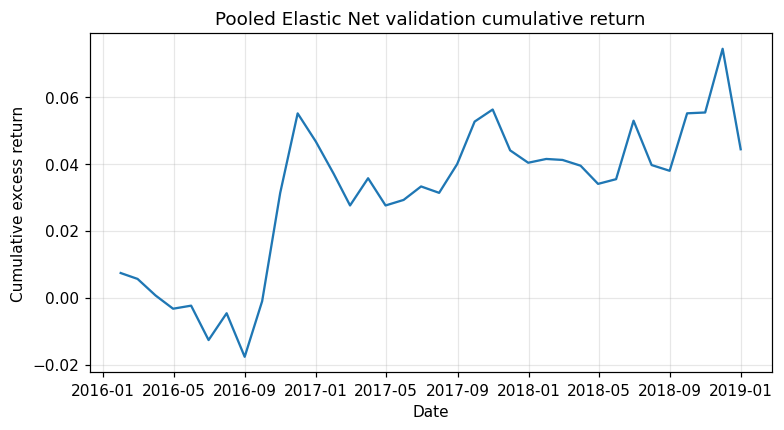

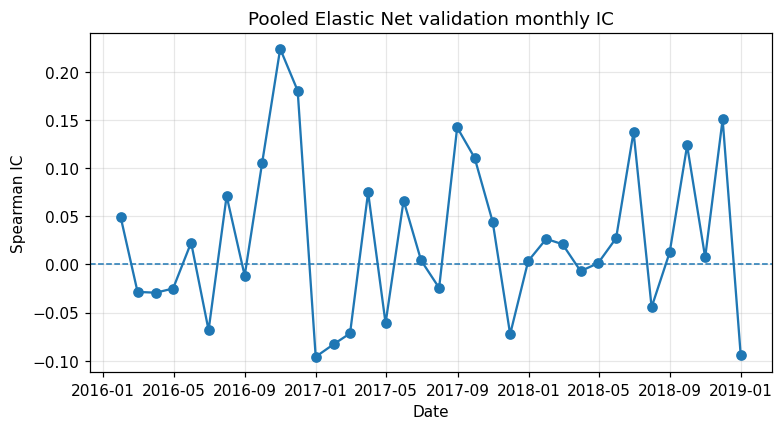

In [95]:
# Cumulative validation portfolio return.
pooled_valid_cumret = (1 + pooled_valid_pf_returns).cumprod() - 1

plt.figure(figsize=(8, 4))
plt.plot(pooled_valid_cumret.index, pooled_valid_cumret.values)
plt.xlabel("Date")
plt.ylabel("Cumulative excess return")
plt.title("Pooled Elastic Net validation cumulative return")
plt.grid(True, alpha=0.3)
plt.show()


# Monthly IC over time.
plt.figure(figsize=(8, 4))
plt.plot(pooled_valid_monthly_ic.index, pooled_valid_monthly_ic.values, marker="o")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Date")
plt.ylabel("Spearman IC")
plt.title("Pooled Elastic Net validation monthly IC")
plt.grid(True, alpha=0.3)
plt.show()

### g. inspect selected coefficients

In [ ]:
# Use the original training period only for coefficient interpretation.
train_for_pooled_coef = valid_update_window[pd.Timestamp("2016-01-01")][0].copy()

X_train_coef = train_for_pooled_coef[log_prediction_features].copy()
y_train_coef = train_for_pooled_coef[target].copy()

pooled_enet_coef_model = ElasticNet(
    alpha=alpha_pooled_star,
    l1_ratio=l1_ratio_pooled_star,
    fit_intercept=True,
    max_iter=10000,
    random_state=42
)

pooled_enet_coef_model.fit(X_train_coef, y_train_coef)

pooled_coef_df = pd.DataFrame({
    "feature": log_prediction_features,
    "coefficient": pooled_enet_coef_model.coef_
})

pooled_coef_df["abs_coefficient"] = pooled_coef_df["coefficient"].abs()

pooled_coef_df = pooled_coef_df.sort_values(
    "abs_coefficient",
    ascending=False
).reset_index(drop=True)

display(pooled_coef_df)

,feature,coefficient,abs_coefficient
0,rvol_21d,-0.006171,0.006171
1,be_me,0.004919,0.004919
2,beta_252d,0.004663,0.004663
3,ret_2_0,0.003100,0.003100
4,gp_at,0.002403,0.002403
5,qmj,0.002224,0.002224
6,ret_24_12,-0.001973,0.001973
7,turnover_126d,-0.001681,0.001681
8,log_me,-0.001331,0.001331
9,at_gr1,-0.001197,0.001197


## 2.4. Clustered Elastic Net Tuning (Fixed K)

**Objective**

Tune the main model of the project: the cluster-conditional Elastic Net.

**Model idea**

The clustered Elastic Net uses:
- base prediction variables,
- cluster dummies,
- predictor-by-cluster interactions.

This allows the predictive effect of each characteristic to vary across firm clusters.

**Tuning task**

With `K^*` fixed from the clustering step, we tune:
- `alpha_clustered`
- `l1_ratio_clustered`

using the validation-period expanding-window forecasting exercise.

**What this section should do**

For each candidate combination of `alpha` and `l1_ratio_clustered`:
1. at each validation refit date, fit k-means on the current expanding estimation window using fixed \(K^*\),
2. assign validation-block observations to the nearest centroids,
3. construct the final clustered design matrix,
4. fit clustered Elastic Net on the current estimation window,
5. generate predictions for the next validation block,
6. construct the validation-period portfolio,
7. evaluate overall validation Sharpe ratio across all validation blocks.

At the end of this section, we select:
- `alpha_clustered*`,
- `l1_ratio_clustered*`.



### a. Function Defining

#### i. Fit K-means and assign cluster labels


In [104]:
def fit_assign_kmeans_clusters(
    est_df,
    pred_df,
    cluster_feature_cols,
    K,
    random_state=42,
    n_init=20,
    cluster_col="cluster"
):
    """
    Fit K-means on the estimation window and assign cluster labels to
    both the estimation window and the next prediction block.

    Parameters
    ----------
    est_df : pandas DataFrame
        Processed estimation-window dataframe.

    pred_df : pandas DataFrame
        Processed prediction-block dataframe.

    cluster_feature_cols : list
        Processed clustering variables, e.g. log_cluster_features.

    K : int
        Fixed number of clusters selected from Section 2.1.

    random_state : int
        Random seed for reproducibility.

    n_init : int
        Number of random initializations used by KMeans.
        K-means can be sensitive to initial centroid locations, so using
        multiple initializations helps find a more stable solution.

    cluster_col : str
        Name of the column used to store cluster labels.

    Returns
    -------
    est_out : pandas DataFrame
        Estimation-window dataframe with cluster labels added.

    pred_out : pandas DataFrame
        Prediction-block dataframe with cluster labels added.

    kmeans_model : fitted sklearn KMeans object
        Fitted K-means model for this refit window.

    Important
    ---------
    K-means is fitted only on the estimation window.
    The prediction block is assigned to the nearest estimated centroids.
    This avoids look-ahead bias.
    """

    # Work on copies to avoid modifying original dataframes.
    est_out = est_df.copy()
    pred_out = pred_df.copy()

    # Extract clustering matrices.
    X_cluster_est = est_out[cluster_feature_cols].copy()
    X_cluster_pred = pred_out[cluster_feature_cols].copy()

    # Defensive checks.
    assert X_cluster_est.isna().sum().sum() == 0, "Missing values in estimation clustering matrix."
    assert X_cluster_pred.isna().sum().sum() == 0, "Missing values in prediction clustering matrix."

    # Fit K-means using only the current estimation window.
    kmeans_model = KMeans(
        n_clusters=K,
        random_state=random_state,
        n_init=n_init
    )

    # fit_predict:
    # - fits K-means on X_cluster_est
    # - returns cluster labels for estimation observations
    est_out[cluster_col] = kmeans_model.fit_predict(X_cluster_est)

    # predict:
    # - does not refit K-means
    # - assigns prediction-block observations to nearest fitted centroid
    pred_out[cluster_col] = kmeans_model.predict(X_cluster_pred)

    return est_out, pred_out, kmeans_model

#### ii. Build clustered Elastic Net design matrix


In [105]:
def build_clustered_design_matrix(
    df,
    feature_cols,
    K,
    cluster_col="cluster",
    baseline_cluster=0
):
    """
    Build the design matrix for clustered Elastic Net.

    The design matrix contains:
    1. base prediction variables
    2. cluster dummy variables
    3. prediction variable × cluster dummy interactions

    Parameters
    ----------
    df : pandas DataFrame
        Processed dataframe with cluster labels.

    feature_cols : list
        Processed prediction variables, e.g. log_prediction_features.

    K : int
        Fixed number of clusters.

    cluster_col : str
        Name of the cluster label column.

    baseline_cluster : int
        Cluster used as the omitted baseline category.
        We drop one cluster dummy to avoid redundant dummy variables.

    Returns
    -------
    X_design : pandas DataFrame
        Clustered design matrix.

    design_cols : list
        Names of all columns in X_design.

    Interpretation
    --------------
    Suppose K = 4 and baseline_cluster = 0.

    The model includes:
    - base predictors for cluster 0
    - cluster_1, cluster_2, cluster_3 dummy intercept shifts
    - feature × cluster_1 interactions
    - feature × cluster_2 interactions
    - feature × cluster_3 interactions

    This allows slopes to differ by cluster.
    """

    df = df.copy()

    # Base prediction variables.
    # These are included for all firms.
    X_base = df[feature_cols].copy().astype(float)

    # Create cluster dummy variables.
    #
    # Example:
    # cluster labels: 0, 1, 2, 3
    # dummy columns: cluster_0, cluster_1, cluster_2, cluster_3
    cluster_dummies = pd.get_dummies(
        df[cluster_col],
        prefix="cluster"
    ).astype(float)

    # Ensure all cluster dummy columns exist.
    # This is important because in a small block, it is possible that one
    # cluster is not observed. We still need a consistent design matrix.
    for k in range(K):
        col = f"cluster_{k}"
        if col not in cluster_dummies.columns:
            cluster_dummies[col] = 0.0

    # Sort dummy columns by cluster number.
    cluster_dummy_cols_all = [f"cluster_{k}" for k in range(K)]
    cluster_dummies = cluster_dummies[cluster_dummy_cols_all]

    # Drop the baseline cluster dummy.
    #
    # Reason:
    # If we include an intercept and all K cluster dummies, the design matrix
    # has redundant information. Dropping one dummy avoids perfect collinearity.
    cluster_dummy_cols = [
        f"cluster_{k}"
        for k in range(K)
        if k != baseline_cluster
    ]

    D = cluster_dummies[cluster_dummy_cols].copy()

    # Build interaction terms:
    # each prediction feature multiplied by each non-baseline cluster dummy.
    interaction_dfs = []

    for dummy_col in cluster_dummy_cols:

        # For one cluster dummy, multiply every feature by that dummy.
        # If a stock is in that cluster, interaction = feature value.
        # If not, interaction = 0.
        interaction_block = X_base.multiply(D[dummy_col], axis=0)

        # Rename interaction columns clearly.
        interaction_block.columns = [
            f"{feature}_x_{dummy_col}"
            for feature in feature_cols
        ]

        interaction_dfs.append(interaction_block)

    # Combine base features, cluster dummies, and interactions.
    X_design = pd.concat(
        [X_base, D] + interaction_dfs,
        axis=1
    )

    design_cols = list(X_design.columns)

    return X_design, design_cols

#### iii. Build aligned clustered train and prediction matrices

In [106]:
def build_aligned_clustered_design_matrices(
    est_df,
    pred_df,
    feature_cols,
    K,
    cluster_col="cluster",
    baseline_cluster=0
):
    """
    Build clustered design matrices for estimation and prediction blocks.

    This function ensures the two matrices have exactly the same columns
    in the same order.

    This is important because ElasticNet is fitted on X_train and then
    used to predict X_pred. The columns must match exactly.
    """

    # Build estimation design matrix.
    X_est, design_cols_est = build_clustered_design_matrix(
        df=est_df,
        feature_cols=feature_cols,
        K=K,
        cluster_col=cluster_col,
        baseline_cluster=baseline_cluster
    )

    # Build prediction-block design matrix.
    X_pred, design_cols_pred = build_clustered_design_matrix(
        df=pred_df,
        feature_cols=feature_cols,
        K=K,
        cluster_col=cluster_col,
        baseline_cluster=baseline_cluster
    )

    # Align prediction matrix to estimation matrix columns.
    #
    # reindex(columns=...) ensures:
    # - same columns
    # - same column order
    # - missing columns filled with 0
    X_pred = X_pred.reindex(columns=design_cols_est, fill_value=0.0)

    # Defensive check.
    assert list(X_est.columns) == list(X_pred.columns), "Train and prediction design columns do not match."

    return X_est, X_pred, design_cols_est

#### iv. Fit clustered Elastic Net and predict one validation block

In [107]:
def fit_predict_clustered_elasticnet(
    est_df,
    pred_df,
    alpha,
    l1_ratio,
    prediction_feature_cols,
    cluster_feature_cols,
    target_col,
    K,
    id_col="id",
    date_col="eom",
    cluster_col="cluster",
    baseline_cluster=0,
    random_state=42
):
    """
    Fit clustered Elastic Net on one estimation window and predict one future block.

    Procedure
    ---------
    1. Fit K-means on estimation-window clustering features.
    2. Assign clusters to estimation and prediction observations.
    3. Build clustered interaction design matrices.
    4. Fit Elastic Net.
    5. Predict the next validation block.

    Returns
    -------
    pred_out : pandas DataFrame
        Stock-level prediction output.

    model : fitted ElasticNet object
        Fitted clustered Elastic Net model.

    kmeans_model : fitted KMeans object
        Fitted K-means model for this refit window.

    design_cols : list
        Names of clustered design matrix columns.
    """

    # --------------------------------------------------------
    # 1. Fit K-means and assign cluster labels
    # --------------------------------------------------------

    est_with_cluster, pred_with_cluster, kmeans_model = fit_assign_kmeans_clusters(
        est_df=est_df,
        pred_df=pred_df,
        cluster_feature_cols=cluster_feature_cols,
        K=K,
        random_state=random_state,
        n_init=20,
        cluster_col=cluster_col
    )

    # --------------------------------------------------------
    # 2. Build clustered design matrices
    # --------------------------------------------------------

    X_train, X_pred, design_cols = build_aligned_clustered_design_matrices(
        est_df=est_with_cluster,
        pred_df=pred_with_cluster,
        feature_cols=prediction_feature_cols,
        K=K,
        cluster_col=cluster_col,
        baseline_cluster=baseline_cluster
    )

    y_train = est_with_cluster[target_col].copy()

    # --------------------------------------------------------
    # 3. Fit Elastic Net on clustered design matrix
    # --------------------------------------------------------

    # Clustered design matrix is larger than pooled design matrix because it
    # includes dummies and interactions. Elastic Net regularization helps
    # control overfitting in this higher-dimensional setup.
    model = ElasticNet(
        alpha=alpha,
        l1_ratio=l1_ratio,
        fit_intercept=True,
        max_iter=10000,
        random_state=random_state
    )

    model.fit(X_train, y_train)

    # --------------------------------------------------------
    # 4. Predict next validation block
    # --------------------------------------------------------

    y_pred = model.predict(X_pred)

    # Historical-average benchmark prediction.
    # Used later for OOS R² comparison.
    ha_pred = y_train.mean()

    # Store clean prediction output.
    pred_out = pred_with_cluster[[id_col, date_col, target_col, cluster_col]].copy()
    pred_out["y_pred"] = y_pred
    pred_out["y_pred_ha"] = ha_pred
    pred_out["alpha"] = alpha
    pred_out["l1_ratio"] = l1_ratio

    return pred_out, model, kmeans_model, design_cols

#### v. Tune clustered Elastic Net over validation expanding windows

In [108]:
def tune_clustered_elasticnet(
    valid_update_window,
    alpha_grid,
    l1_ratio_grid,
    prediction_feature_cols,
    cluster_feature_cols,
    target_col,
    K,
    id_col="id",
    date_col="eom",
    cluster_col="cluster",
    baseline_cluster=0,
    min_stocks_per_month=20,
    random_state=42
):
    """
    Tune clustered Elastic Net using validation-period expanding-window forecasts.

    For each alpha and l1_ratio:
        1. Loop over validation refit dates.
        2. Fit K-means on current estimation window.
        3. Assign clusters to estimation and validation block.
        4. Build clustered interaction design matrix.
        5. Fit Elastic Net.
        6. Predict next validation block.
        7. Combine validation predictions.
        8. Evaluate OOS R², IC, and portfolio Sharpe.

    Returns
    -------
    tuning_results_df : pandas DataFrame
        One row per hyperparameter pair.

    all_prediction_dict : dict
        Stores detailed outputs for each hyperparameter pair.
    """

    tuning_results = []
    all_prediction_dict = {}

    # Create all hyperparameter combinations.
    hyperparameter_grid = list(itertools.product(alpha_grid, l1_ratio_grid))

    for alpha, l1_ratio in hyperparameter_grid:

        print(f"Running clustered Elastic Net: alpha={alpha}, l1_ratio={l1_ratio}, K={K}")

        window_predictions = []
        window_design_cols = []

        # Loop over validation expanding-window blocks.
        for refit_date, (est_df, pred_df) in valid_update_window.items():

            pred_out, model, kmeans_model, design_cols = fit_predict_clustered_elasticnet(
                est_df=est_df,
                pred_df=pred_df,
                alpha=alpha,
                l1_ratio=l1_ratio,
                prediction_feature_cols=prediction_feature_cols,
                cluster_feature_cols=cluster_feature_cols,
                target_col=target_col,
                K=K,
                id_col=id_col,
                date_col=date_col,
                cluster_col=cluster_col,
                baseline_cluster=baseline_cluster,
                random_state=random_state
            )

            # Record which refit window produced this prediction.
            pred_out["refit_date"] = refit_date

            window_predictions.append(pred_out)
            window_design_cols.append(design_cols)

        # Combine predictions across all validation blocks.
        combined_pred_df = (
            pd.concat(window_predictions, axis=0)
            .sort_values([date_col, id_col])
            .reset_index(drop=True)
        )

        # Evaluate this hyperparameter pair using the same function as pooled Elastic Net.
        # This keeps the comparison fair.
        results, pf_returns, monthly_ic, weight_df = evaluate_prediction_results(
            pred_df=combined_pred_df,
            target_col=target_col,
            pred_col="y_pred",
            ha_pred_col="y_pred_ha",
            date_col=date_col,
            id_col=id_col,
            min_stocks_per_month=min_stocks_per_month
        )

        # Store summary results.
        result_row = {
            "alpha": alpha,
            "l1_ratio": l1_ratio,
            "K": K,
            **results
        }

        tuning_results.append(result_row)

        # Store detailed outputs.
        all_prediction_dict[(alpha, l1_ratio)] = {
            "predictions": combined_pred_df,
            "portfolio_returns": pf_returns,
            "monthly_ic": monthly_ic,
            "weights": weight_df,
            "design_cols_by_window": window_design_cols
        }

    tuning_results_df = pd.DataFrame(tuning_results)

    # Sort by validation Sharpe because this is the main tuning criterion.
    tuning_results_df = tuning_results_df.sort_values(
        by="sharpe",
        ascending=False
    ).reset_index(drop=True)

    return tuning_results_df, all_prediction_dict

### b. Hyperparameter grid for clustered Elastic Net


In [ ]:
# Clustered Elastic Net has more columns than pooled Elastic Net because it
# includes cluster dummies and feature-by-cluster interactions.
# Therefore, it may need slightly stronger regularization.

alpha_grid_clustered = [
    0.0005,
    0.0008,
    0.0010,
    0.0015,
    0.0020,
    0.0030,
    0.0050,
    0.01
]

# l1_ratio controls the L1/L2 mixture.
# Moderate values allow both shrinkage and variable selection.
l1_ratio_grid_clustered = [
    0.4,
    0.5,
    0.6,
    0.7,
    1.0
]

### c. Run clustered Elastic Net validation tuning

In [116]:
clustered_enet_tuning_results, clustered_enet_outputs = tune_clustered_elasticnet(
    valid_update_window=valid_update_window,
    alpha_grid=alpha_grid_clustered,
    l1_ratio_grid=l1_ratio_grid_clustered,
    prediction_feature_cols=log_prediction_features,
    cluster_feature_cols=log_cluster_features,
    target_col=target,
    K=K_star,
    id_col="id",
    date_col="eom",
    cluster_col="cluster",
    baseline_cluster=0,
    min_stocks_per_month=20,
    random_state=42
)

display(clustered_enet_tuning_results)

Running clustered Elastic Net: alpha=0.0005, l1_ratio=0.4, K=4
Running clustered Elastic Net: alpha=0.0005, l1_ratio=0.5, K=4
Running clustered Elastic Net: alpha=0.0005, l1_ratio=0.6, K=4
Running clustered Elastic Net: alpha=0.0005, l1_ratio=0.7, K=4
Running clustered Elastic Net: alpha=0.0008, l1_ratio=0.4, K=4
Running clustered Elastic Net: alpha=0.0008, l1_ratio=0.5, K=4
Running clustered Elastic Net: alpha=0.0008, l1_ratio=0.6, K=4
Running clustered Elastic Net: alpha=0.0008, l1_ratio=0.7, K=4
Running clustered Elastic Net: alpha=0.001, l1_ratio=0.4, K=4
Running clustered Elastic Net: alpha=0.001, l1_ratio=0.5, K=4
Running clustered Elastic Net: alpha=0.001, l1_ratio=0.6, K=4
Running clustered Elastic Net: alpha=0.001, l1_ratio=0.7, K=4
Running clustered Elastic Net: alpha=0.0015, l1_ratio=0.4, K=4
Running clustered Elastic Net: alpha=0.0015, l1_ratio=0.5, K=4
Running clustered Elastic Net: alpha=0.0015, l1_ratio=0.6, K=4
Running clustered Elastic Net: alpha=0.0015, l1_ratio=0.7, 

d:\Python\envs\fina4713\Lib\site-packages\pandas\core\nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


Running clustered Elastic Net: alpha=0.01, l1_ratio=0.6, K=4


d:\Python\envs\fina4713\Lib\site-packages\pandas\core\nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


Running clustered Elastic Net: alpha=0.01, l1_ratio=0.7, K=4


d:\Python\envs\fina4713\Lib\site-packages\pandas\core\nanops.py:1661: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


,alpha,l1_ratio,K,oos_r2,mse_model,mse_ha,mean_ic,std_ic,ic_tstat,ann_return,ann_vol,sharpe,n_months,n_obs
0,0.0005,0.4,4,-0.002475,0.022500,0.022444,0.020403,0.076405,1.602236,0.014488,0.038093,0.380334,36,132695
1,0.0008,0.5,4,-0.001848,0.022486,0.022444,0.024331,0.079086,1.845904,0.015201,0.039982,0.380189,36,132695
2,0.0010,0.4,4,-0.001847,0.022486,0.022444,0.024342,0.079092,1.846566,0.015203,0.039990,0.380163,36,132695
3,0.0005,0.7,4,-0.002008,0.022490,0.022444,0.023299,0.078564,1.779405,0.014884,0.039557,0.376264,36,132695
4,0.0005,0.5,4,-0.002291,0.022496,0.022444,0.021304,0.077125,1.657354,0.014463,0.038600,0.374699,36,132695
5,0.0008,0.4,4,-0.002084,0.022491,0.022444,0.022659,0.078151,1.739646,0.014658,0.039295,0.373033,36,132695
6,0.0005,0.6,4,-0.002142,0.022493,0.022444,0.022217,0.077831,1.712739,0.014526,0.039070,0.371790,36,132695
7,0.0008,0.6,4,-0.001729,0.022483,0.022444,0.025155,0.080137,1.883358,0.014832,0.040651,0.364870,36,132695
8,0.0010,0.5,4,-0.001704,0.022483,0.022444,0.025298,0.080351,1.889032,0.014647,0.040787,0.359109,36,132695
9,0.0008,0.7,4,-0.001635,0.022481,0.022444,0.025643,0.080887,1.902127,0.014074,0.041122,0.342244,36,132695


### e. Select BEST clustered Elastic Net hyperparameters


In [117]:
# Main criterion: validation Sharpe ratio.
best_clustered_row = clustered_enet_tuning_results.iloc[0]

alpha_clustered_star = best_clustered_row["alpha"]
l1_ratio_clustered_star = best_clustered_row["l1_ratio"]

print("Best clustered Elastic Net hyperparameters:")
print("alpha_clustered_star    =", alpha_clustered_star)
print("l1_ratio_clustered_star =", l1_ratio_clustered_star)
print("K_star                  =", K_star)

print("\nValidation performance of selected clustered Elastic Net:")
display(best_clustered_row.to_frame().T)

Best clustered Elastic Net hyperparameters:
alpha_clustered_star    = 0.0005
l1_ratio_clustered_star = 0.4
K_star                  = 4

Validation performance of selected clustered Elastic Net:


,alpha,l1_ratio,K,oos_r2,mse_model,mse_ha,mean_ic,std_ic,ic_tstat,ann_return,ann_vol,sharpe,n_months,n_obs
0,0.0005,0.4,4.0,-0.002475,0.0225,0.022444,0.020403,0.076405,1.602236,0.014488,0.038093,0.380334,36.0,132695.0


### f. Retrieve detailed validation outputs for selected clustered Elastic Net


In [118]:
# Create dictionary key for the selected hyperparameter pair.
best_clustered_key = (alpha_clustered_star, l1_ratio_clustered_star)

# Stock-level validation predictions.
# Includes:
# - id
# - eom
# - realized return
# - assigned cluster
# - clustered Elastic Net prediction
# - historical-average benchmark prediction
# - hyperparameter values
# - refit_date
clustered_valid_pred = clustered_enet_outputs[best_clustered_key]["predictions"]

# Monthly validation long-short portfolio returns.
clustered_valid_pf_returns = clustered_enet_outputs[best_clustered_key]["portfolio_returns"]

# Monthly Spearman IC values.
clustered_valid_monthly_ic = clustered_enet_outputs[best_clustered_key]["monthly_ic"]

# Stock-level portfolio weights.
clustered_valid_weights = clustered_enet_outputs[best_clustered_key]["weights"]

# Design matrix column names for each validation window.
# Useful for checking the number of regressors created by dummies and interactions.
clustered_design_cols_by_window = clustered_enet_outputs[best_clustered_key]["design_cols_by_window"]

print("Selected clustered Elastic Net key:", best_clustered_key)
print("Combined validation prediction shape:", clustered_valid_pred.shape)
print("Number of validation portfolio-return months:", len(clustered_valid_pf_returns))
print("Number of validation IC months:", len(clustered_valid_monthly_ic))
print("Number of design columns in first window:", len(clustered_design_cols_by_window[0]))

display(clustered_valid_pred.head())
display(clustered_valid_pf_returns.head())
display(clustered_valid_monthly_ic.head())
display(clustered_valid_weights.head())

Selected clustered Elastic Net key: (np.float64(0.0005), np.float64(0.4))
Combined validation prediction shape: (132695, 9)
Number of validation portfolio-return months: 36
Number of validation IC months: 36
Number of design columns in first window: 103


,id,eom,ret_exc_lead1m,cluster,y_pred,y_pred_ha,alpha,l1_ratio,refit_date
0,10001.0,2016-01-31,-0.055493,2,0.006610,0.004763,0.0005,0.4,2016-01-01
1,10025.0,2016-01-31,-0.070266,2,-0.001825,0.004763,0.0005,0.4,2016-01-01
2,10026.0,2016-01-31,0.025818,2,0.004841,0.004763,0.0005,0.4,2016-01-01
3,10032.0,2016-01-31,0.040997,0,-0.000558,0.004763,0.0005,0.4,2016-01-01
4,10044.0,2016-01-31,-0.003073,2,0.000404,0.004763,0.0005,0.4,2016-01-01


eom
2016-01-31    0.008147
2016-02-29   -0.000987
2016-03-31   -0.004154
2016-04-30   -0.006399
2016-05-31    0.000946
Name: portfolio_return, dtype: float64

eom
2016-01-31    0.058869
2016-02-29   -0.030508
2016-03-31   -0.041626
2016-04-30   -0.049997
2016-05-31    0.028551
dtype: float64

,id,eom,ret_exc_lead1m,cluster,y_pred,y_pred_ha,alpha,l1_ratio,refit_date,weight,weighted_return
0,10001.0,2016-01-31,-0.055493,2,0.006610,0.004763,0.0005,0.4,2016-01-01,0.000352,-1.955387e-05
1,10025.0,2016-01-31,-0.070266,2,-0.001825,0.004763,0.0005,0.4,2016-01-01,-0.000099,6.921867e-06
2,10026.0,2016-01-31,0.025818,2,0.004841,0.004763,0.0005,0.4,2016-01-01,0.000274,7.065597e-06
3,10032.0,2016-01-31,0.040997,0,-0.000558,0.004763,0.0005,0.4,2016-01-01,-0.000032,-1.305103e-06
4,10044.0,2016-01-31,-0.003073,2,0.000404,0.004763,0.0005,0.4,2016-01-01,0.000019,-5.920063e-08


### g. Quick validation diagnostics for selected clustered Elastic Net


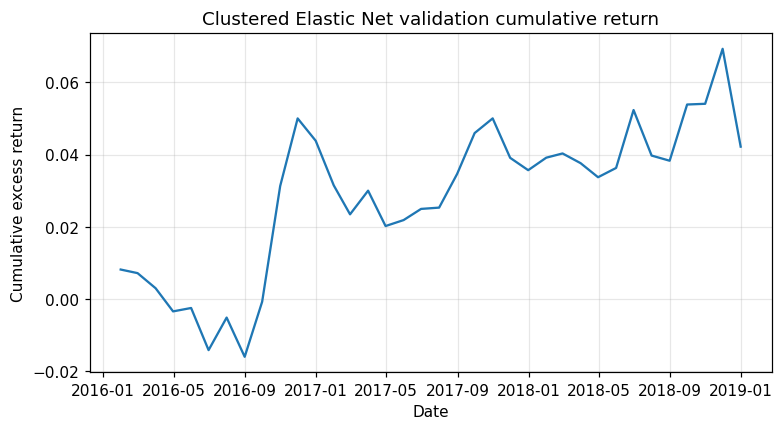

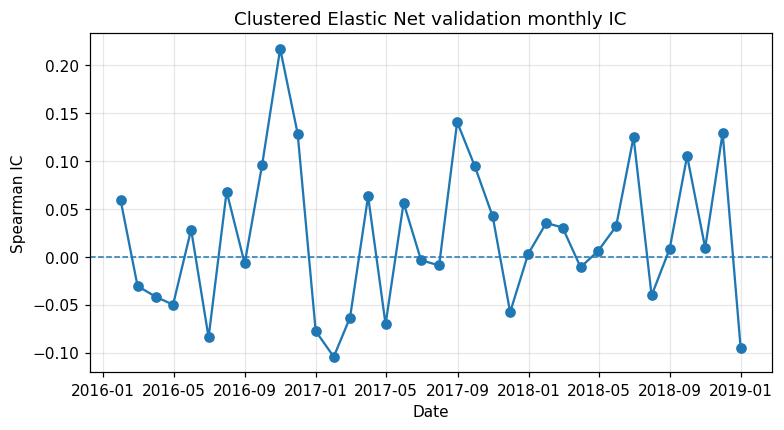

In [119]:
# Cumulative validation portfolio return.
clustered_valid_cumret = (1 + clustered_valid_pf_returns).cumprod() - 1

plt.figure(figsize=(8, 4))
plt.plot(clustered_valid_cumret.index, clustered_valid_cumret.values)
plt.xlabel("Date")
plt.ylabel("Cumulative excess return")
plt.title("Clustered Elastic Net validation cumulative return")
plt.grid(True, alpha=0.3)
plt.show()


# Monthly IC over time.
plt.figure(figsize=(8, 4))
plt.plot(
    clustered_valid_monthly_ic.index,
    clustered_valid_monthly_ic.values,
    marker="o"
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Date")
plt.ylabel("Spearman IC")
plt.title("Clustered Elastic Net validation monthly IC")
plt.grid(True, alpha=0.3)
plt.show()

### h. Compare selected pooled and clustered Elastic Net validation performance


In [ ]:
# Best pooled result from Section 2.3.
pooled_best_summary = best_pooled_row.to_frame().T.copy()
pooled_best_summary["model"] = "Pooled Elastic Net"

# Best clustered result from this section.
clustered_best_summary = best_clustered_row.to_frame().T.copy()
clustered_best_summary["model"] = "Clustered Elastic Net"

# Combine and reorder columns.
enet_validation_comparison = pd.concat(
    [pooled_best_summary, clustered_best_summary],
    axis=0,
    ignore_index=True
)

cols_order = [
    "model",
    "alpha",
    "l1_ratio",
    "K",
    "oos_r2",
    "mean_ic",
    "ic_tstat",
    "ann_return",
    "ann_vol",
    "sharpe",
    "n_months",
    "n_obs"
]

# Pooled Elastic Net does not have K, so fill missing K with NaN.
for col in cols_order:
    if col not in enet_validation_comparison.columns:
        enet_validation_comparison[col] = np.nan

enet_validation_comparison = enet_validation_comparison[cols_order]

display(enet_validation_comparison)

,model,alpha,l1_ratio,K,oos_r2,mean_ic,ic_tstat,ann_return,ann_vol,sharpe,n_months,n_obs
0,Pooled Elastic Net,0.0010,0.4,NaN,-0.001713,0.024731,1.822807,0.015274,0.040830,0.374094,36.0,132695.0
1,Clustered Elastic Net,0.0005,0.4,4.0,-0.002475,0.020403,1.602236,0.014488,0.038093,0.380334,36.0,132695.0


: 

# 3. Final Model Estimation

This section estimates the finalized comparison models using the tuned specifications from the previous section. No further hyperparameter search is conducted here.

The final comparison set includes:
- Historical-average benchmark,
- Pooled OLS,
- Pooled Elastic Net,
- Clustered Elastic Net.

All models will later be run under the same 6-month expanding-window update protocol.

## 3.1. Historical-average benchmark

### Model idea
At each refit date, predict every stock-month observation using the average `ret_exc_lead1m` in the current estimation window.

This historical-average benchmark does not use stock characteristics and does not generate cross-sectional variation in predictions. Its main role is to provide the null benchmark for out-of-sample \(R^2\).

### Useful visualizations
- cumulative return curve for the benchmark portfolio,
- histogram of benchmark predictions,
- summary statistics of stock-level historical means.

## 3.2. OLS Baseline

### Objective
Estimate the pooled linear benchmark without regularization or cluster structure.

### Model idea
Use the processed predictor set in a pooled cross-sectional OLS regression.

### What this section should do
- build the pooled OLS design matrix,
- fit OLS on the current estimation window,
- generate stock-level predictions for the next forecast block.

### Why we do it
This is the required linear baseline and provides the benchmark for judging whether regularization and cluster-conditioning add value.

### Useful visualizations
- coefficient table for a selected refit date,
- coefficient stability plot across refit windows,
- predicted-vs-realized scatterplot for a validation block.

## 3.3. Pooled Elastic Net

### Objective
Estimate the tuned regularized non-clustered benchmark.

### Model idea
Use the same base predictors as the clustered model, but without cluster dummies or interaction terms.

### Hyperparameters
Use the tuned:
- `alpha_pooled*`
- `l1_ratio_pooled*`

### What this section should do
- fit pooled Elastic Net on each estimation window using the fixed pooled hyperparameters,
- generate stock-level predictions for the next forecast block.

### Why we do it
This model isolates the effect of regularization. Comparing it with clustered Elastic Net tells us whether cluster-conditioning adds value beyond a non-clustered regularized benchmark.

### Useful visualizations
- active-coefficient count over time,
- comparison of active predictors vs OLS coefficients,
- coefficient-path plot for the selected pooled model.

## 3.4. Clustered Elastic Net

### Objective
Estimate the main model of the project using the tuned clustered specification.

### Model idea
The final clustered Elastic Net includes:
- base predictors,
- cluster dummies,
- predictor-by-cluster interactions.

### Hyperparameters
Use the tuned:
- `K^*`
- `alpha_clustered*`
- `l1_ratio_clustered*`

### What this section should do
- re-estimate k-means centroids with fixed \(K^*\),
- assign cluster labels,
- construct cluster dummies and predictor-by-cluster interactions,
- fit clustered Elastic Net with the fixed clustered hyperparameters,
- generate stock-level predictions for the next forecast block.

### Why we do it
This is the core model used to test whether predictor effects differ across firm types and whether allowing such heterogeneity improves prediction and portfolio performance.

### Useful visualizations
- active interaction count over time,
- top interaction coefficients table,
- coefficient heatmap by predictor and cluster,
- comparison of predicted-return distributions from pooled vs clustered Elastic Net.

# 4. Model Evaluation and Comparison

This section evaluates the finalized models under the common forecasting protocol and reports the final out-of-sample predictive results. Since the validation period is now used for model tuning, the main formal evaluation is conducted on the untouched test period. We also summarize how the 6-month expanding-window updating scheme is implemented and interpret the economic meaning of the final clustered model.

## 4.1. 6-month Updating

### Objective
Implement the agreed forecasting protocol used in both the validation tuning exercise and the final test-period evaluation.

### Update rule
- expanding window,
- refit every 6 months.

### What updates every 6 months
- preprocessing objects,
- cluster centroids,
- model coefficients.

### What remains fixed
- chosen number of clusters \(K^*\),
- pooled Elastic Net hyperparameters,
- clustered Elastic Net hyperparameters,
- predictor sets,
- overall model structure.

### Why we do it
This allows the models to adapt to newly available data while preserving a fixed design and avoiding repeated redefinition of the full methodology. The same update logic is used consistently throughout the forecasting exercise, with only past information available at each refit date.

## 4.2. Test Evaluation

### Objective
Evaluate final out-of-sample predictive performance on the official test period.

### Test period
- 2019-01 to 2024-12

### What this section should do
- run the finalized models using the same 6-month expanding-window protocol,
- generate monthly stock-level predictions for each model,
- compute the final out-of-sample predictive metrics on the untouched test sample.

### Models evaluated
- Historical-average benchmark
- Pooled OLS
- Pooled Elastic Net
- Clustered Elastic Net

### Required predictive output
Report test out-of-sample \(R^2\) for each model.

### Why this matters
This is the main formal performance evaluation stage of the project, because the validation period has already been used for model tuning.

### Useful visualizations
- test \(R^2\) comparison chart,
- predicted-return decile vs realized-return plot,
- predicted vs realized return scatter or binned plot.

## 4.3. Cluster Interpretation and Diagnostics

### Objective
Interpret the selected clustering structure and explain the economic meaning of the final clustered model.

### What this section should do
- summarize the selected centroids using the clustering variables,
- label each cluster economically,
- compare cluster sizes under the selected \(K^*\),
- examine which predictor-by-cluster effects remain active in the final clustered Elastic Net,
- assess whether the final model tells a coherent finance story.

### Why this matters
The clustered model is valuable only if the selected clusters are not just statistically distinct, but also economically meaningful. This section connects the final ML results back to the underlying finance question.

### Useful visualizations
- centroid heatmap,
- cluster-size distribution,
- boxplots of important clustering variables by cluster,
- PCA scatter plot colored by cluster for visualization only,
- heatmap of active predictor-by-cluster coefficients,
- ranked table of the most important interaction effects.

# 5. Portfolio Construction

This section applies the previously defined portfolio rule to the final test-period predictions from each model. The purpose here is not to redefine the portfolio formation method, but to evaluate the economic performance of the benchmark and machine-learning models under a common trading rule.

## 5.1 Final Portfolio Application

### Objective
Apply the portfolio rule defined earlier in the tuning stage to the final test-period predictions.

### What this section should do
- take the monthly stock-level predictions from each finalized model,
- apply the common rank-based long–short weighting rule,
- compute the resulting monthly portfolio returns over the test period.

### Why this section is separate
The portfolio rule itself is defined earlier because it is already needed for Sharpe-based hyperparameter tuning. Here, we simply apply that same fixed rule to the final out-of-sample predictions so that portfolio performance is evaluated consistently across models.

## 5.2. Final Portfolio Performance

### Objective
Evaluate the economic performance of the portfolios generated by each final prediction model.

### What this section should do
- summarize monthly test-period long–short returns for each model,
- compare benchmark, linear, and machine-learning strategies on an economic basis.

### Report
For each model, report:
- annualized mean excess return,
- annualized volatility,
- Sharpe ratio.

### Useful visualizations
- cumulative return curves across models,
- bar chart of annualized return / volatility / Sharpe,
- drawdown plot,
- monthly return distribution plot.

## 5.3. Implementation Discussion

### Objective
Discuss whether the test-period portfolio results are likely to survive real-world trading frictions.

### What this section should do
Provide a qualitative discussion of:
- turnover,
- transaction costs,
- liquidity constraints,
- concentration risk,
- whether the strategy remains economically plausible after implementation frictions.

### Why we do it
The project guideline explicitly asks for a qualitative discussion of implementation issues, even if they are not modeled quantitatively.